In [1]:
import os
import pickle 
import joblib
import pandas as pd
import numpy as np
import random
import itertools
from datetime import datetime, timedelta
import matplotlib.dates as mdates

import matplotlib.pyplot as plt
plt.style.use('tableau-colorblind10')

import sys
sys.path.append('/data/Hydra_Work/Competition_Functions') 
from Processing_Functions import process_forecast_date, process_seasonal_forecasts
from Data_Transforming import read_nested_csvs, generate_daily_flow, use_USGS_flow_data, USGS_to_daily_df_yearly
from Full_LSTM_ML_Functions import SumPinballLoss


sys.path.append('/data/Hydra_Work/Pipeline_Functions')
from Folder_Work import filter_rows_by_year, csv_dictionary, add_day_of_year_column


from datetime import datetime
import torch
import torch.nn as nn


In [2]:
"""import os
import shutil

# Define the base directory
base_dir = "/data/Hydra_Work/3_Day_No_Forecast_Validation_Models"

# Define the set of Val_Years and Models
val_years = list(range(2000, 2024, 2))  # Even years between 2000 and 2024
model1 = "General_LSTM_Model"
model2 = "General_LSTM_No_Flow_Model"

# Function to swap the contents of two directories
def swap_directories(dir1, dir2):inksc
    temp_dir = dir1 + "_temp"
    # Move dir1 to temp_dir
    shutil.move(dir1, temp_dir)
    # Move dir2 to dir1
    shutil.move(dir2, dir1)
    # Move temp_dir to dir2
    shutil.move(temp_dir, dir2)

# Swap the contents for each year
for year in val_years:
    dir1 = os.path.join(base_dir, str(year), model1)
    dir2 = os.path.join(base_dir, str(year), model2)
    swap_directories(dir1, dir2)
    print(f"Swapped contents of {dir1} and {dir2}")
"""

'import os\nimport shutil\n\n# Define the base directory\nbase_dir = "/data/Hydra_Work/3_Day_No_Forecast_Validation_Models"\n\n# Define the set of Val_Years and Models\nval_years = list(range(2000, 2024, 2))  # Even years between 2000 and 2024\nmodel1 = "General_LSTM_Model"\nmodel2 = "General_LSTM_No_Flow_Model"\n\n# Function to swap the contents of two directories\ndef swap_directories(dir1, dir2):inksc\n    temp_dir = dir1 + "_temp"\n    # Move dir1 to temp_dir\n    shutil.move(dir1, temp_dir)\n    # Move dir2 to dir1\n    shutil.move(dir2, dir1)\n    # Move temp_dir to dir2\n    shutil.move(temp_dir, dir2)\n\n# Swap the contents for each year\nfor year in val_years:\n    dir1 = os.path.join(base_dir, str(year), model1)\n    dir2 = os.path.join(base_dir, str(year), model2)\n    swap_directories(dir1, dir2)\n    print(f"Swapped contents of {dir1} and {dir2}")\n'

In [3]:
basins = ['libby_reservoir_inflow',  'owyhee_r_bl_owyhee_dam',  'san_joaquin_river_millerton_reservoir',  'taylor_park_reservoir_inflow',
 'boise_r_nr_boise', 'green_r_bl_howard_a_hanson_dam', 'weber_r_nr_oakley', 'detroit_lake_inflow', 'virgin_r_at_virtin', 'dillon_reservoir_inflow',
 'pueblo_reservoir_inflow', 'hungry_horse_reservoir_inflow', 'stehekin_r_at_stehekin', 'pecos_r_nr_pecos', 'snake_r_nr_heise', 'yampa_r_nr_maybell',
 'colville_r_at_kettle_falls', 'missouri_r_at_toston', 'merced_river_yosemite_at_pohono_bridge', 'animas_r_at_durango','fontenelle_reservoir_inflow', 'boysen_reservoir_inflow']

len(basins)

22

In [4]:
basins = ['libby_reservoir_inflow',  'owyhee_r_bl_owyhee_dam',  'san_joaquin_river_millerton_reservoir',  'taylor_park_reservoir_inflow',
 'boise_r_nr_boise', 'green_r_bl_howard_a_hanson_dam', 'weber_r_nr_oakley', 'detroit_lake_inflow', 'virgin_r_at_virtin', 'dillon_reservoir_inflow',
 'pueblo_reservoir_inflow', 'hungry_horse_reservoir_inflow', 'stehekin_r_at_stehekin', 'pecos_r_nr_pecos', 'snake_r_nr_heise', 'yampa_r_nr_maybell',
 'colville_r_at_kettle_falls', 'missouri_r_at_toston', 'merced_river_yosemite_at_pohono_bridge', 'animas_r_at_durango','fontenelle_reservoir_inflow', 'boysen_reservoir_inflow']

selected_years = range(2001,2023,1)


base_dir = "/data/Hydra_Work/Scaled_Data"

# Define dictionaries and DataFrames
dictionaries = ['era5', 'seasonal_forecasts', 'daily_flow', 'climatological_flows']

dataframes = ['climate_indices', 'clustering_static_variables'] # remove clustering for hand chosen

# Function to load dictionaries
def load_dictionaries(base_dir, names):
    loaded_dicts = {}
    for name in names:
        file_path = os.path.join(base_dir, f"{name}.pkl")
        with open(file_path, 'rb') as file:
            locals()[name] = pickle.load(file)
    return locals()

# Function to load DataFrames
def load_dataframes(base_dir, names):
    loaded_dfs = {}
    for name in names:
        file_path = os.path.join(base_dir, f"{name}.pkl")
        locals()[name] = pd.read_pickle(file_path)
    return locals()

saved_dicts = load_dictionaries(base_dir, dictionaries)
saved_dfs = load_dataframes(base_dir, dataframes)

for name in dictionaries:
    locals()[name] = saved_dicts[name]

for name in dataframes:
    locals()[name] = saved_dfs[name]

criterion = SumPinballLoss(quantiles = [0.1, 0.5, 0.9])

basin = 'animas_r_at_durango' 
All_Dates = daily_flow[basin].index[
    ((daily_flow[basin].index.month < 6) | ((daily_flow[basin].index.month == 6) & (daily_flow[basin].index.day < 24))) &
    ((daily_flow[basin].index.year % 2 == 0) | ((daily_flow[basin].index.month > 10) | ((daily_flow[basin].index.month == 10) & (daily_flow[basin].index.day >= 1))))
]
All_Dates = All_Dates[All_Dates.year > 1998]


# Validation Year
Val_Dates = All_Dates[All_Dates.year >= 2020]
All_Dates = All_Dates[All_Dates.year < 2020]

device = torch.device('cuda' if torch.cuda.
                is_available() else 'cpu')



static_variables = clustering_static_variables

In [5]:
def calculate_climatological_flows(years_to_include, daily_flow):
    climatological_flows = {}

    for basin, df in daily_flow.items():
        df = df[df.index.year.isin(years_to_include)].copy()
        # Extract day of year and flow values
        df['day_of_year'] = df.index.dayofyear

        grouped = df.groupby('day_of_year')['daily_flow'].quantile([0.1, 0.5, 0.9]).unstack(level=1)

        climatological_flows[basin] = pd.DataFrame({
            'day_of_year': grouped.index,
            '10th_percentile_flow': grouped[0.1],
            '50th_percentile_flow': grouped[0.5],
            '90th_percentile_flow': grouped[0.9]
        })
        
        climatological_flows[basin].set_index('day_of_year', inplace=True)

        # Drop the temporary 'day_of_year' column from the original dataframe
        df.drop(columns='day_of_year', inplace=True)
    return climatological_flows

In [6]:
test_year = 2008
years = np.arange(2001,2024,1)
years_to_include = new_list = [year for year in years if year != test_year]
print(years_to_include)
climatological_flows = calculate_climatological_flows(years_to_include, daily_flow)
climatological_flows['animas_r_at_durango']


[2001, 2002, 2003, 2004, 2005, 2006, 2007, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


,10th_percentile_flow,50th_percentile_flow,90th_percentile_flow
day_of_year,,,
1,-0.614270,-0.576359,-0.525026
2,-0.629574,-0.579302,-0.530324
3,-0.638755,-0.575770,-0.530321
4,-0.636167,-0.574593,-0.525612
5,-0.634048,-0.577536,-0.518548
...,...,...,...
361,-0.600847,-0.575775,-0.508669
362,-0.606851,-0.585781,-0.509964
363,-0.616504,-0.586953,-0.495601


# Evaluation Plots

In [7]:
import joblib
import sys
sys.path.append('/data/Hydra_Work/Performance_Evaluation') 
from Evaluation_Functions import test_weekly_performance, test_weekly_performance_hydra, quantile_loss,  normalised_quantile_loss



In [8]:
era5 = joblib.load('/data/Hydra_Work/Sep_2024_Data/scaled_data/normalized_era5.pkl')
daily_flow = joblib.load('/data/Hydra_Work/Sep_2024_Data/scaled_data_Sep_05/normalized_daily_flow.pkl')

climatological_flows = joblib.load('/data/Hydra_Work/Sep_2024_Data/scaled_data_Sep_05/normalized_climatological_flows.pkl')
static_variables = pd.read_csv('/data/Hydra_Work/Sep_2024_Data/scaled_data/static_variables_normalized.csv')
static_variables.set_index('site_id', inplace = True)

device = torch.device('cuda' if torch.cuda.
                is_available() else 'cpu')

criterion = SumPinballLoss(quantiles = [0.1, 0.5, 0.9])

basin = 'animas_r_at_durango' 
All_Dates = daily_flow[basin].index[
    ((daily_flow[basin].index.month < 6) | ((daily_flow[basin].index.month == 6) & (daily_flow[basin].index.day < 24))) &
    ((daily_flow[basin].index.year % 2 == 0))
]

All_Dates = daily_flow[basin].index[
    ((daily_flow[basin].index.month < 6) | ((daily_flow[basin].index.month == 6) & (daily_flow[basin].index.day < 24)))
]
All_Dates = All_Dates[All_Dates.year > 1998]
All_Dates = All_Dates[All_Dates.year < 2023]

seed = 42 ; torch.manual_seed(seed) ; random.seed(seed) ; np.random.seed(seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

days  = 90


for key, basin in daily_flow.items():
    daily_flow[key].rename(columns={'00060': 'daily_flow'}, inplace=True)
seasonal_forecasts = era5
    

In [9]:
def Matrix_Of_CV_Scores(basins, years):
    day = 1
    Scores = {}
    n = 0
    for test_year in years:
        
        General_LSTM_Model = torch.load(f'/data/Hydra_Work/Sep_{day}_Day_No_Forecast_Validation_Models/{test_year}/General_LSTM_Model/General_LSTM.pth')
        General_LSTM_No_Flow_Model = torch.load(f'/data/Hydra_Work/Sep_{day}_Day_No_Forecast_Validation_Models/{test_year}/General_LSTM_No_Flow_Model/General_LSTM.pth')
        Hydra_General_Head = torch.load(f'/data/Hydra_Work/Sep_{day}_Day_No_Forecast_Validation_Models_Seperate_V2/{test_year}/General_Head_Model/Hydra_Head_LSTM.pth')
        Hydra_Body = torch.load(f'/data/Hydra_Work/Sep_{day}_Day_No_Forecast_Validation_Models_Seperate_V2/{test_year}/General_Head_Model/Hydra_Body_LSTM.pth')
        Flag_LSTM = torch.load(f'/data/Hydra_Work/Sep_{day}_Day_No_Forecast_Validation_Models/{test_year}/Flag_LSTM_Model/Flag_LSTM.pth')

        years_to_include = [year for year in years if year != test_year]
        climatological_flows = calculate_climatological_flows(years_to_include, daily_flow)


        for basin in basins:
            
            Specific_Heads = {}
            Specific_Models = {}
            Specific_Heads[f'{basin}'] = torch.load(f'/data/Hydra_Work/Sep_{day}_Day_No_Forecast_Validation_Models_Seperate_V2/{test_year}/Basin_Head_Model/{basin}.path')
            Specific_Models[f'{basin}'] = torch.load(f'/data/Hydra_Work/Sep_{day}_Day_No_Forecast_Validation_Models/{test_year}/Specific_LSTM_Model/{basin}_specific.pth') 
                            
            start_season_date = f'{test_year}-01-01' 
            end_season_date = f'{test_year}-06-26'

            Climatology_Guesses, Basin_Head_Guesses, General_Head_Guesses,  Truth = test_weekly_performance_hydra(basin, Hydra_Body, Hydra_General_Head, Specific_Heads, era5, seasonal_forecasts, daily_flow, climatological_flows, climate_indices, static_variables, device, end_season_date, start_season_date,  furthest_distance = 120,  group_lengths = [1], feed_forcing = False, days = day)
            _, General_LSTM_Guesses,  _ = test_weekly_performance(basin, General_LSTM_Model, era5, seasonal_forecasts, daily_flow, climatological_flows, climate_indices, static_variables, device, end_season_date, start_season_date,  furthest_distance = 120,  group_lengths = [1], feed_forcing = False, specialised = False, days = day)
            _, General_LSTM_No_Flow_Guesses,  _ = test_weekly_performance(basin, General_LSTM_No_Flow_Model, era5, seasonal_forecasts, daily_flow, climatological_flows, climate_indices, static_variables, device, end_season_date, start_season_date,  furthest_distance = 120,  group_lengths = [1], feed_forcing = False, specialised = False, Flow = False, days = day)
            _, Specific_LSTM_Guesses, _ = test_weekly_performance(basin, Specific_Models, era5, seasonal_forecasts, daily_flow, climatological_flows, climate_indices, static_variables, device, end_season_date, start_season_date,  furthest_distance = 120,  group_lengths = [1], feed_forcing = False, specialised = True, days = day)
            _, No_Flow_Flag_LSTM_Guesses, _ = test_weekly_performance(basin, Flag_LSTM, era5, seasonal_forecasts, daily_flow, climatological_flows, climate_indices, static_variables, device, end_season_date, start_season_date, furthest_distance=120, group_lengths=[1], feed_forcing=False, specialised=False, p = 0, days = day)
            _, Flag_LSTM_Guesses, _ = test_weekly_performance(basin, Flag_LSTM, era5, seasonal_forecasts, daily_flow, climatological_flows, climate_indices, static_variables, device, end_season_date, start_season_date, furthest_distance=120, group_lengths=[1], feed_forcing=False, specialised=False, p = 1, days = day)
            # Conversion of outputs
            Days = len(Flag_LSTM_Guesses)

            # Quantile loss calculation
            quantiles = np.array([0.1, 0.5, 0.9])
            Days = len(Basin_Head_Guesses)
            Basin_Head_Guesses = np.array(Basin_Head_Guesses).reshape(Days , 3)
            General_Head_Guesses = np.array(General_Head_Guesses).reshape(Days , 3)
            General_LSTM_No_Flow_Guesses = np.array(General_LSTM_No_Flow_Guesses).reshape(Days , 3)
            Climatology_Guesses = np.array(Climatology_Guesses).reshape(Days , 3)

            General_LSTM_Guesses = np.array(General_LSTM_Guesses).reshape(Days , 3)
            Specific_LSTM_Guesses = np.array(Specific_LSTM_Guesses).reshape(Days , 3)
            No_Flow_Flag_LSTM_Guesses = np.array(No_Flow_Flag_LSTM_Guesses).reshape(Days, 3)
            Flag_LSTM_Guesses = np.array(Flag_LSTM_Guesses).reshape(Days, 3)

            Truth = np.array(Truth)


            model_names = [
                "Climatology", 
                "Single-Catchment_Hydra_Head", "Multi-Catchment_Hydra_Head",
                "Multi-Catchment_LSTM:_With_River_Discharge", "Multi-Catchment_LSTM:_Without_River_Discharge", 
                "Flag_LSTM:_With_River_Discharge", "Flag_LSTM:_Without_River_Discharge", 
                "Single-Catchment_LSTM:_With_River_Discharge"
            ]


            Outputs = [Climatology_Guesses, Basin_Head_Guesses, General_Head_Guesses, General_LSTM_Guesses, General_LSTM_No_Flow_Guesses, Flag_LSTM_Guesses, No_Flow_Flag_LSTM_Guesses , Specific_LSTM_Guesses]

            # model_names = ["Climatology_Model", "Basin_Hydra_Head_Model", "General_Hydra_Head_Model", "General_LSTM_Model:_With_River_Discharge",  "General_LSTM_Model:_Without_River_Discharge", "Flag_LSTM_Model:_Without_River_Discharge", "Flag_LSTM_Model:_With_River_Discharge"]
            # Outputs = [Climatology_Guesses, Basin_Head_Guesses, General_Head_Guesses, General_LSTM_Guesses, General_LSTM_No_Flow_Guesses, No_Flow_Flag_LSTM_Guesses, Flag_LSTM_Guesses]


            
            for model_name, Output in zip(model_names, Outputs):
                Scores[f'{basin}_{test_year}_{model_name}'] = normalised_quantile_loss(Output, Truth, quantiles, Climatology_Guesses)
        n = n+1
        print(f"{n} Years done")            
        
    return Scores 
    
years = np.arange(2000,2024,2)



In [10]:
def Flag_LSTM_Matrix_Of_CV_Scores(basins, years, index = 0):
    day = 1
    Scores = {}
    n = 0
    for test_year in years:
        
        Hydra_General_Head = torch.load(f'/data/Hydra_Work/Sep_{day}_Day_No_Forecast_Validation_Models_Seperate_V2/{test_year}/General_Head_Model/Hydra_Head_LSTM.pth')
        Hydra_Body = torch.load(f'/data/Hydra_Work/Sep_{day}_Day_No_Forecast_Validation_Models_Seperate_V2/{test_year}/General_Head_Model/Hydra_Body_LSTM.pth')
        Flag_LSTM = torch.load(f'/data/Hydra_Work/Sep_{day}_Day_No_Forecast_Validation_Models/{test_year}/Flag_LSTM_Model/Flag_LSTM.pth')

        years_to_include = [year for year in years if year != test_year]
        climatological_flows = calculate_climatological_flows(years_to_include, daily_flow)


        for basin in basins:
            
            Specific_Heads = {}
            Specific_Models = {}
            Specific_Heads[f'{basin}'] = torch.load(f'/data/Hydra_Work/Sep_{day}_Day_No_Forecast_Validation_Models_Seperate_V2/2001/Basin_Head_Model/{basin}.path')

            start_season_date = f'{test_year}-01-01' 
            end_season_date = f'{test_year}-06-26'

            Climatology_Guesses, Basin_Head_Guesses, General_Head_Guesses,  Truth = test_weekly_performance_hydra(basin, Hydra_Body, Hydra_General_Head, Specific_Heads, era5, seasonal_forecasts, daily_flow, climatological_flows, climate_indices, static_variables, device, end_season_date, start_season_date,  furthest_distance = 120,  group_lengths = [1], feed_forcing = False, days = day)
            _, No_Flow_Flag_LSTM_Guesses, _ = test_weekly_performance(basin, Flag_LSTM, era5, seasonal_forecasts, daily_flow, climatological_flows, climate_indices, static_variables, device, end_season_date, start_season_date, furthest_distance=120, group_lengths=[1], feed_forcing=False, specialised=False, p = 0, days = day)
            _, Flag_LSTM_Guesses, _ = test_weekly_performance(basin, Flag_LSTM, era5, seasonal_forecasts, daily_flow, climatological_flows, climate_indices, static_variables, device, end_season_date, start_season_date, furthest_distance=120, group_lengths=[1], feed_forcing=False, specialised=False, p = 1, days = day)
            # Conversion of outputs
            Days = len(Flag_LSTM_Guesses)

            # Quantile loss calculation
            quantiles = np.array([0.1, 0.5, 0.9])
            Days = len(Basin_Head_Guesses)
            Climatology_Guesses = np.array(Climatology_Guesses).reshape(Days , 3)

            No_Flow_Flag_LSTM_Guesses = np.array(No_Flow_Flag_LSTM_Guesses).reshape(Days, 3)
            Flag_LSTM_Guesses = np.array(Flag_LSTM_Guesses).reshape(Days, 3)

            Truth = np.array(Truth)


            model_names = [
                "Climatology", 
                "Flag_LSTM:_With_River_Discharge", "Flag_LSTM:_Without_River_Discharge", 
                            ]


            Outputs = [Climatology_Guesses, Flag_LSTM_Guesses, No_Flow_Flag_LSTM_Guesses]

            # model_names = ["Climatology_Model", "Basin_Hydra_Head_Model", "General_Hydra_Head_Model", "General_LSTM_Model:_With_River_Discharge",  "General_LSTM_Model:_Without_River_Discharge", "Flag_LSTM_Model:_Without_River_Discharge", "Flag_LSTM_Model:_With_River_Discharge"]
            # Outputs = [Climatology_Guesses, Basin_Head_Guesses, General_Head_Guesses, General_LSTM_Guesses, General_LSTM_No_Flow_Guesses, No_Flow_Flag_LSTM_Guesses, Flag_LSTM_Guesses]


            
            # for model_name, Output in zip(model_names, Outputs):
            #     Scores[f'{basin}_{test_year}_{model_name}'] = normalised_quantile_loss(Output, Truth, quantiles, Climatology_Guesses)

            Truth = Truth.squeeze()
            for model_name, Output in zip(model_names, Outputs):
                # The following code shows the proportion of times the model is exceeded by the truth at the index specified
                Scores[f'{basin}_{test_year}_{model_name}'] = (Output[:,index] < Truth).sum() / len(Truth)
        n = n+1
        print(f"{n} Years done")            
        
    return Scores 



In [11]:
def Matrix_Of_Exceedance_Scores(basins, years, index = 0):
    day = 1
    Scores = {}
    n = 0
    for test_year in years:

        General_LSTM_Model = torch.load(f'/data/Hydra_Work/Sep_{day}_Day_No_Forecast_Validation_Models/{test_year}/General_LSTM_Model/General_LSTM.pth')
        General_LSTM_No_Flow_Model = torch.load(f'/data/Hydra_Work/Sep_{day}_Day_No_Forecast_Validation_Models/{test_year}/General_LSTM_No_Flow_Model/General_LSTM.pth')
        Hydra_General_Head = torch.load(f'/data/Hydra_Work/Sep_{day}_Day_No_Forecast_Validation_Models_Seperate_V2/{test_year}/General_Head_Model/Hydra_Head_LSTM.pth')
        Hydra_Body = torch.load(f'/data/Hydra_Work/Sep_{day}_Day_No_Forecast_Validation_Models_Seperate_V2/{test_year}/General_Head_Model/Hydra_Body_LSTM.pth')
        Flag_LSTM = torch.load(f'/data/Hydra_Work/Sep_{day}_Day_No_Forecast_Validation_Models/{test_year}/Flag_LSTM_Model/Flag_LSTM.pth')
                        
        years_to_include = [year for year in years if year != test_year]
        climatological_flows = calculate_climatological_flows(years_to_include, daily_flow)


        for basin in basins:
            Specific_Heads = {}
            Specific_Models = {}
            Specific_Heads[f'{basin}'] = torch.load(f'/data/Hydra_Work/Sep_{day}_Day_No_Forecast_Validation_Models_Seperate_V2/{test_year}/Basin_Head_Model/{basin}.path')
            Specific_Models[f'{basin}'] = torch.load(f'/data/Hydra_Work/Sep_{day}_Day_No_Forecast_Validation_Models/{test_year}/Specific_LSTM_Model/{basin}_specific.pth') 
                            
            start_season_date = f'{test_year}-01-01' 
            end_season_date = f'{test_year}-06-26'

            Climatology_Guesses, Basin_Head_Guesses, General_Head_Guesses,  Truth = test_weekly_performance_hydra(basin, Hydra_Body, Hydra_General_Head, Specific_Heads, era5, seasonal_forecasts, daily_flow, climatological_flows, climate_indices, static_variables, device, end_season_date, start_season_date,  furthest_distance = 120,  group_lengths = [1], feed_forcing = False, days = day)
            _, General_LSTM_Guesses,  _ = test_weekly_performance(basin, General_LSTM_Model, era5, seasonal_forecasts, daily_flow, climatological_flows, climate_indices, static_variables, device, end_season_date, start_season_date,  furthest_distance = 120,  group_lengths = [1], feed_forcing = False, specialised = False, days = day)
            _, General_LSTM_No_Flow_Guesses,  _ = test_weekly_performance(basin, General_LSTM_No_Flow_Model, era5, seasonal_forecasts, daily_flow, climatological_flows, climate_indices, static_variables, device, end_season_date, start_season_date,  furthest_distance = 120,  group_lengths = [1], feed_forcing = False, specialised = False, Flow = False, days = day)
            _, Specific_LSTM_Guesses, _ = test_weekly_performance(basin, Specific_Models, era5, seasonal_forecasts, daily_flow, climatological_flows, climate_indices, static_variables, device, end_season_date, start_season_date,  furthest_distance = 120,  group_lengths = [1], feed_forcing = False, specialised = True, days = day)
            _, No_Flow_Flag_LSTM_Guesses, _ = test_weekly_performance(basin, Flag_LSTM, era5, seasonal_forecasts, daily_flow, climatological_flows, climate_indices, static_variables, device, end_season_date, start_season_date, furthest_distance=120, group_lengths=[1], feed_forcing=False, specialised=False, p = 0, days = day)
            _, Flag_LSTM_Guesses, _ = test_weekly_performance(basin, Flag_LSTM, era5, seasonal_forecasts, daily_flow, climatological_flows, climate_indices, static_variables, device, end_season_date, start_season_date, furthest_distance=120, group_lengths=[1], feed_forcing=False, specialised=False, p = 1, days = day)
            # Conversion of outputs
            Days = len(Flag_LSTM_Guesses)

            # Quantile loss calculation
            quantiles = np.array([0.1, 0.5, 0.9])
            Days = len(Basin_Head_Guesses)
            Basin_Head_Guesses = np.array(Basin_Head_Guesses).reshape(Days , 3)
            General_Head_Guesses = np.array(General_Head_Guesses).reshape(Days , 3)
            General_LSTM_No_Flow_Guesses = np.array(General_LSTM_No_Flow_Guesses).reshape(Days , 3)
            Climatology_Guesses = np.array(Climatology_Guesses).reshape(Days , 3)

            General_LSTM_Guesses = np.array(General_LSTM_Guesses).reshape(Days , 3)
            Specific_LSTM_Guesses = np.array(Specific_LSTM_Guesses).reshape(Days , 3)
            No_Flow_Flag_LSTM_Guesses = np.array(No_Flow_Flag_LSTM_Guesses).reshape(Days, 3)
            Flag_LSTM_Guesses = np.array(Flag_LSTM_Guesses).reshape(Days, 3)

            Truth = np.array(Truth)

            model_names = [
                "Climatology", 
                "Single-Catchment_Hydra_Head", "Multi-Catchment_Hydra_Head",
                "Multi-Catchment_LSTM:_With_River_Discharge", "Multi-Catchment_LSTM:_Without_River_Discharge", 
                "Flag_LSTM:_With_River_Discharge", "Flag_LSTM:_Without_River_Discharge", 
                "Single-Catchment_LSTM:_With_River_Discharge"
            ]


            Outputs = [Climatology_Guesses, Basin_Head_Guesses, General_Head_Guesses, General_LSTM_Guesses, General_LSTM_No_Flow_Guesses, Flag_LSTM_Guesses, No_Flow_Flag_LSTM_Guesses , Specific_LSTM_Guesses]


            # model_names = ["Climatology_Model", "Basin_Hydra_Head_Model", "General_Hydra_Head_Model", "General_LSTM_Model:_With_River_Discharge",  "General_LSTM_Model:_Without_River_Discharge", "Flag_LSTM_Model:_Without_River_Discharge", "Flag_LSTM_Model:_With_River_Discharge"]
            # Outputs = [Climatology_Guesses, Basin_Head_Guesses, General_Head_Guesses, General_LSTM_Guesses, General_LSTM_No_Flow_Guesses, No_Flow_Flag_LSTM_Guesses, Flag_LSTM_Guesses]


            Truth = Truth.squeeze()
            for model_name, Output in zip(model_names, Outputs):
                # The following code shows the proportion of times the model is exceeded by the truth at the index specified
                Scores[f'{basin}_{test_year}_{model_name}'] = (Output[:,index] < Truth).sum() / len(Truth)
        n = n+1
        print(f"{n} Years done")            

    return Scores 
    
# years = np.arange(2000,2024,2)

In [12]:
seasonal_forecasts = era5

In [13]:
basins = ['libby_reservoir_inflow',  'owyhee_r_bl_owyhee_dam',  'san_joaquin_river_millerton_reservoir',  'taylor_park_reservoir_inflow',
 'green_r_bl_howard_a_hanson_dam', 'weber_r_nr_oakley', 'detroit_lake_inflow', 'virgin_r_at_virtin', 'dillon_reservoir_inflow',
  'hungry_horse_reservoir_inflow', 'stehekin_r_at_stehekin', 'pecos_r_nr_pecos', 'snake_r_nr_heise', 'yampa_r_nr_maybell',
 'colville_r_at_kettle_falls', 'missouri_r_at_toston', 'merced_river_yosemite_at_pohono_bridge', 'animas_r_at_durango']


In [ ]:
years = np.arange(2001,2023,2)
Upper_Exc_Scores = Matrix_Of_Exceedance_Scores(basins, years, index = 2)
Middle_Exc_Scores = Matrix_Of_Exceedance_Scores(basins, years, index = 1)
Lower_Exc_Scores = Matrix_Of_Exceedance_Scores(basins, years, index = 0)

In [ ]:
years = np.arange(2001,2023,2)

CV_Scores = Matrix_Of_CV_Scores(basins, years)

In [ ]:
years = np.arange(2001,2023,2)
Flag_CV = Flag_LSTM_Matrix_Of_CV_Scores(basins, years, index = 2)

In [15]:
#remove san_joaqsan_joaquin_river_millerton_reservoir from the list basins
small_basins = ['libby_reservoir_inflow',  'owyhee_r_bl_owyhee_dam',  'taylor_park_reservoir_inflow',
 'boise_r_nr_boise', 'green_r_bl_howard_a_hanson_dam', 'weber_r_nr_oakley', 'detroit_lake_inflow', 'virgin_r_at_virtin', 'dillon_reservoir_inflow',
 'pueblo_reservoir_inflow', 'hungry_horse_reservoir_inflow', 'stehekin_r_at_stehekin', 'pecos_r_nr_pecos', 'snake_r_nr_heise', 'yampa_r_nr_maybell',
 'colville_r_at_kettle_falls', 'missouri_r_at_toston', 'merced_river_yosemite_at_pohono_bridge', 'animas_r_at_durango','fontenelle_reservoir_inflow', 'boysen_reservoir_inflow']

In [16]:
import pickle


Date = '19_09'
# # # # Save the dictionary to a file
with open(f'/data/Hydra_Work/Validation_Results/1_Day_{Date}_Validation_High_Exceedance_Dict.pkl', 'wb') as f:
   pickle.dump(Upper_Exc_Scores, f)

with open(f'/data/Hydra_Work/Validation_Results/1_Day_{Date}_Validation_Middle_Exceedance_Dict.pkl', 'wb') as f:
   pickle.dump(Middle_Exc_Scores, f)
   
with open(f'/data/Hydra_Work/Validation_Results/1_Day_{Date}_Validation_Low_Exceedance_Dict.pkl', 'wb') as f:
   pickle.dump(Lower_Exc_Scores, f)

with open(f'/data/Hydra_Work/Validation_Results/1_Day_{Date}_Validation_Dict.pkl', 'wb') as f:
   pickle.dump(CV_Scores, f)

#Load the dictionary from a file
# with open('/data/Hydra_Work/Validation_Results/1_Day_28_06_Validation_Dict.pkl', 'rb') as f:
#     Scores = pickle.load(f)


# Scores = {key.replace('_Flow', '_River_Discharge'): value for key, value in Scores.items()}



In [16]:
import pickle


Date = '19_09'
with open(f'/data/Hydra_Work/Validation_Results/1_Day_{Date}_Validation_Dict.pkl', 'wb') as f:
   pickle.dump(CV_Scores, f)


In [14]:
import pickle
Date = '19_09'
years = np.arange(2001,2023,2)

# File paths
file_paths = {
    'Upper_Exc_Scores': f'/data/Hydra_Work/Validation_Results/1_Day_{Date}_Validation_High_Exceedance_Dict.pkl',
    'Middle_Exc_Scores': f'/data/Hydra_Work/Validation_Results/1_Day_{Date}_Validation_Middle_Exceedance_Dict.pkl',
    'Lower_Exc_Scores': f'/data/Hydra_Work/Validation_Results/1_Day_{Date}_Validation_Low_Exceedance_Dict.pkl',
    'CV_Scores': f'/data/Hydra_Work/Validation_Results/1_Day_{Date}_Validation_Dict.pkl'
}

# Load the data from the pickle files
Upper_Exc_Scores = pickle.load(open(file_paths['Upper_Exc_Scores'], 'rb'))
Middle_Exc_Scores = pickle.load(open(file_paths['Middle_Exc_Scores'], 'rb'))
Lower_Exc_Scores = pickle.load(open(file_paths['Lower_Exc_Scores'], 'rb'))
CV_Scores = pickle.load(open(file_paths['CV_Scores'], 'rb'))


In [15]:
Scores = [Upper_Exc_Scores, Middle_Exc_Scores, Lower_Exc_Scores, CV_Scores]

In [16]:
# The swap dictionary
swap_dict = {
    'General': 'Multi-Catchment',
    'Specific_LSTM': 'Single-Catchment_LSTM:_With_River_Discharge',
    'Basin': 'Single-Catchment',
    '_Model': '',
    '_Flow': '_River_Discharge'
}

# Create a new dictionary with the swapped and replaced keys
for Score in Scores:
    new_scores = {}
    for key, value in Score.items():
        new_key = key
        for old, new in swap_dict.items():
            new_key = new_key.replace(old, new)
        new_scores[new_key] = value
        
    Score = new_scores

In [17]:
model_names = [
        "Climatology", 
        "Single-Catchment_Hydra_Head", "Multi-Catchment_Hydra_Head",
        "Multi-Catchment_LSTM:_With_River_Discharge", "Multi-Catchment_LSTM:_Without_River_Discharge", 
        "Single-Catchment_LSTM:_With_River_Discharge", 
        "Flag_LSTM:_With_River_Discharge", "Flag_LSTM:_Without_River_Discharge"
    ]

def calculate_averaged_scores(Score, basins, model_names):    

    # Initialize dictionary to hold scores
    averaged_scores = {model: {basin: [] for basin in basins} for model in model_names}
    model_name_underscore_count = {model: model.count('_') for model in model_names}

    # Extract scores and compute averages
    for key, score in Score.items():
        model_name = None
        # Determine the number of underscores in the model name by matching the end of the key with known model names
        for model in model_names:
            if key.endswith(f'{model}'):
                parts = key.rsplit('_', model_name_underscore_count[model] + 2)  # Split from the end
                basin = '_'.join(parts[:-model_name_underscore_count[model] - 2])  # Reconstruct the basin name
                year = parts[-model_name_underscore_count[model] - 2]
                model_name = model                
        
        if model_name is not None:
            averaged_scores[model_name][basin].append(score)

    # Average the scores over the years
    for model in averaged_scores:
        for basin in averaged_scores[model]:
            averaged_scores[model][basin] = np.mean(averaged_scores[model][basin])

    # Create a DataFrame from the averaged scores
    basins_df = pd.DataFrame(averaged_scores)

    # Add an 'Average' row
    basins_df.loc['Average'] = basins_df.mean(axis=0)

    return basins_df




In [18]:
Upper_Exceedences = calculate_averaged_scores(Upper_Exc_Scores, basins, model_names)
Middle_Exceedences = calculate_averaged_scores(Middle_Exc_Scores, basins, model_names)
Lower_Exceedences = calculate_averaged_scores(Lower_Exc_Scores, basins, model_names)
CV_Values = calculate_averaged_scores(CV_Scores, basins, model_names)

In [19]:
Upper_Exceedences

,Climatology,Single-Catchment_Hydra_Head,Multi-Catchment_Hydra_Head,Multi-Catchment_LSTM:_With_River_Discharge,Multi-Catchment_LSTM:_Without_River_Discharge,Single-Catchment_LSTM:_With_River_Discharge,Flag_LSTM:_With_River_Discharge,Flag_LSTM:_Without_River_Discharge
libby_reservoir_inflow,0.175141,0.088855,0.098613,0.078069,0.089368,0.109399,0.068824,0.388803
owyhee_r_bl_owyhee_dam,0.155624,0.099127,0.117617,0.038521,0.057011,0.150488,0.074987,0.000000
san_joaquin_river_millerton_reservoir,0.171032,0.120185,0.148947,0.042630,0.204931,0.149461,0.064715,0.190036
taylor_park_reservoir_inflow,0.163328,0.103236,0.078069,0.066769,0.107345,0.162301,0.061633,0.181818
green_r_bl_howard_a_hanson_dam,0.177196,0.107345,0.095532,0.085259,0.098613,0.140216,0.135593,0.970211
weber_r_nr_oakley,0.159733,0.129944,0.148433,0.111967,0.115049,0.185927,0.095018,0.393426
detroit_lake_inflow,0.162301,0.127375,0.091936,0.048793,0.084746,0.133025,0.087827,0.990241
virgin_r_at_virtin,0.171032,0.142270,0.134052,0.118644,0.136107,0.152542,0.117103,0.047252
dillon_reservoir_inflow,0.159733,0.122753,0.121212,0.049307,0.129944,0.155110,0.095018,0.176168
hungry_horse_reservoir_inflow,0.172060,0.101695,0.157678,0.059579,0.112481,0.155624,0.067283,0.816641


In [20]:
Lower_Exceedences

,Climatology,Single-Catchment_Hydra_Head,Multi-Catchment_Hydra_Head,Multi-Catchment_LSTM:_With_River_Discharge,Multi-Catchment_LSTM:_Without_River_Discharge,Single-Catchment_LSTM:_With_River_Discharge,Flag_LSTM:_With_River_Discharge,Flag_LSTM:_Without_River_Discharge
libby_reservoir_inflow,0.831022,0.904982,0.856703,0.902928,0.936312,0.879815,0.873138,1.000000
owyhee_r_bl_owyhee_dam,0.827427,0.843349,0.808423,0.896764,0.821777,0.820750,0.923472,0.060606
san_joaquin_river_millerton_reservoir,0.827940,0.880842,0.904468,0.932717,0.812532,0.855675,0.866975,0.629687
taylor_park_reservoir_inflow,0.825886,0.847458,0.793015,0.871084,0.802773,0.868002,0.834617,1.000000
green_r_bl_howard_a_hanson_dam,0.837185,0.858243,0.895737,0.959425,0.833590,0.815614,0.932203,1.000000
weber_r_nr_oakley,0.825372,0.889060,0.911145,0.914741,0.933231,0.817155,0.948639,1.000000
detroit_lake_inflow,0.826400,0.869543,0.927067,0.959425,0.855675,0.787365,0.914227,1.000000
virgin_r_at_virtin,0.830508,0.906523,0.847458,0.889574,0.940421,0.868516,0.912686,0.651772
dillon_reservoir_inflow,0.822291,0.865948,0.866975,0.900360,0.784797,0.883924,0.959425,0.891115
hungry_horse_reservoir_inflow,0.845403,0.883410,0.869029,0.930149,0.861325,0.841294,0.928608,1.000000


In [21]:
CV_Values

,Climatology,Single-Catchment_Hydra_Head,Multi-Catchment_Hydra_Head,Multi-Catchment_LSTM:_With_River_Discharge,Multi-Catchment_LSTM:_Without_River_Discharge,Single-Catchment_LSTM:_With_River_Discharge,Flag_LSTM:_With_River_Discharge,Flag_LSTM:_Without_River_Discharge
libby_reservoir_inflow,0.0,0.747018,0.011135,0.725400,0.072837,0.739487,0.625499,-0.033333
owyhee_r_bl_owyhee_dam,0.0,0.795397,-0.392849,0.438462,-0.152502,0.727970,0.312283,-0.186853
san_joaquin_river_millerton_reservoir,0.0,0.872236,0.177206,0.832710,0.094082,0.858827,0.798654,0.132260
taylor_park_reservoir_inflow,0.0,0.812990,-0.071805,0.691289,-0.057852,0.789199,0.560844,-0.109637
green_r_bl_howard_a_hanson_dam,0.0,0.601593,0.208075,0.593164,0.095278,0.574952,0.474762,0.139146
weber_r_nr_oakley,0.0,0.709360,0.285198,0.671954,0.369837,0.671605,0.621753,0.340122
detroit_lake_inflow,0.0,0.624834,0.058636,0.568897,-0.005124,0.580357,0.473053,-0.004443
virgin_r_at_virtin,0.0,0.714807,0.292830,0.620283,0.387950,0.704028,0.656894,0.391554
dillon_reservoir_inflow,0.0,0.844616,0.134980,0.776159,-0.132490,0.826702,0.743866,-0.125256
hungry_horse_reservoir_inflow,0.0,0.720471,0.014562,0.697768,0.018317,0.692521,0.652565,-0.037422


In [22]:
model_names = [
    "Climatology", 
    "Single-Catchment_Hydra_Head", "Multi-Catchment_Hydra_Head",
    "Multi-Catchment_LSTM:_With_River_Discharge", "Multi-Catchment_LSTM:_Without_River_Discharge", 
    "Single-Catchment_LSTM:_With_River_Discharge", 
    "Flag_LSTM:_With_River_Discharge", "Flag_LSTM:_Without_River_Discharge"
]
averaged_scores = {model: {basin: [] for basin in basins} for model in model_names}
model_name_underscore_count = {model: model.count('_') for model in model_names}

# Extract scores and compute averages
for key, score in CV_Scores.items():
    model_name = None
    # Determine the number of underscores in the model name by matching the end of the key with known model names
    for model in model_names:
        if key.endswith(f'{model}'):
            parts = key.rsplit('_', model_name_underscore_count[model] + 2)  # Split from the end
            basin = '_'.join(parts[:-model_name_underscore_count[model] - 2])  # Reconstruct the basin name
            year = parts[-model_name_underscore_count[model] - 2]
            model_name = model
            
    if basin in basins:
        averaged_scores[model_name][basin].append(score)

# Average the scores over the years
for model in averaged_scores:
    for basin in averaged_scores[model]:
        averaged_scores[model][basin] = np.mean(averaged_scores[model][basin])

# Create a DataFrame from the averaged scores
basins_df = pd.DataFrame(averaged_scores)

average_row = basins_df.mean(axis=0)
basins_df.loc['Average'] = average_row


In [23]:
basins_df

,Climatology,Single-Catchment_Hydra_Head,Multi-Catchment_Hydra_Head,Multi-Catchment_LSTM:_With_River_Discharge,Multi-Catchment_LSTM:_Without_River_Discharge,Single-Catchment_LSTM:_With_River_Discharge,Flag_LSTM:_With_River_Discharge,Flag_LSTM:_Without_River_Discharge
libby_reservoir_inflow,0.0,0.747018,0.011135,0.725400,0.072837,0.739487,0.625499,-0.033333
owyhee_r_bl_owyhee_dam,0.0,0.795397,-0.392849,0.438462,-0.152502,0.727970,0.312283,-0.186853
san_joaquin_river_millerton_reservoir,0.0,0.872236,0.177206,0.832710,0.094082,0.858827,0.798654,0.132260
taylor_park_reservoir_inflow,0.0,0.812990,-0.071805,0.691289,-0.057852,0.789199,0.560844,-0.109637
green_r_bl_howard_a_hanson_dam,0.0,0.601593,0.208075,0.593164,0.095278,0.574952,0.474762,0.139146
weber_r_nr_oakley,0.0,0.709360,0.285198,0.671954,0.369837,0.671605,0.621753,0.340122
detroit_lake_inflow,0.0,0.624834,0.058636,0.568897,-0.005124,0.580357,0.473053,-0.004443
virgin_r_at_virtin,0.0,0.714807,0.292830,0.620283,0.387950,0.704028,0.656894,0.391554
dillon_reservoir_inflow,0.0,0.844616,0.134980,0.776159,-0.132490,0.826702,0.743866,-0.125256
hungry_horse_reservoir_inflow,0.0,0.720471,0.014562,0.697768,0.018317,0.692521,0.652565,-0.037422


In [24]:
def extract_model_scores(Scores, model_name):
    return [score for key, score in Scores.items() if key.endswith(f'_{model_name}')]


def plot_cdf(data, label, colour, threshold=None, log_x_axis=True):
    if threshold is not None:
        data = [x for x in data if x > threshold]
    sorted_data = np.sort(data)
    cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    plt.plot(sorted_data, cdf, label=label, color = colour)
    if log_x_axis:
        plt.xscale('log')



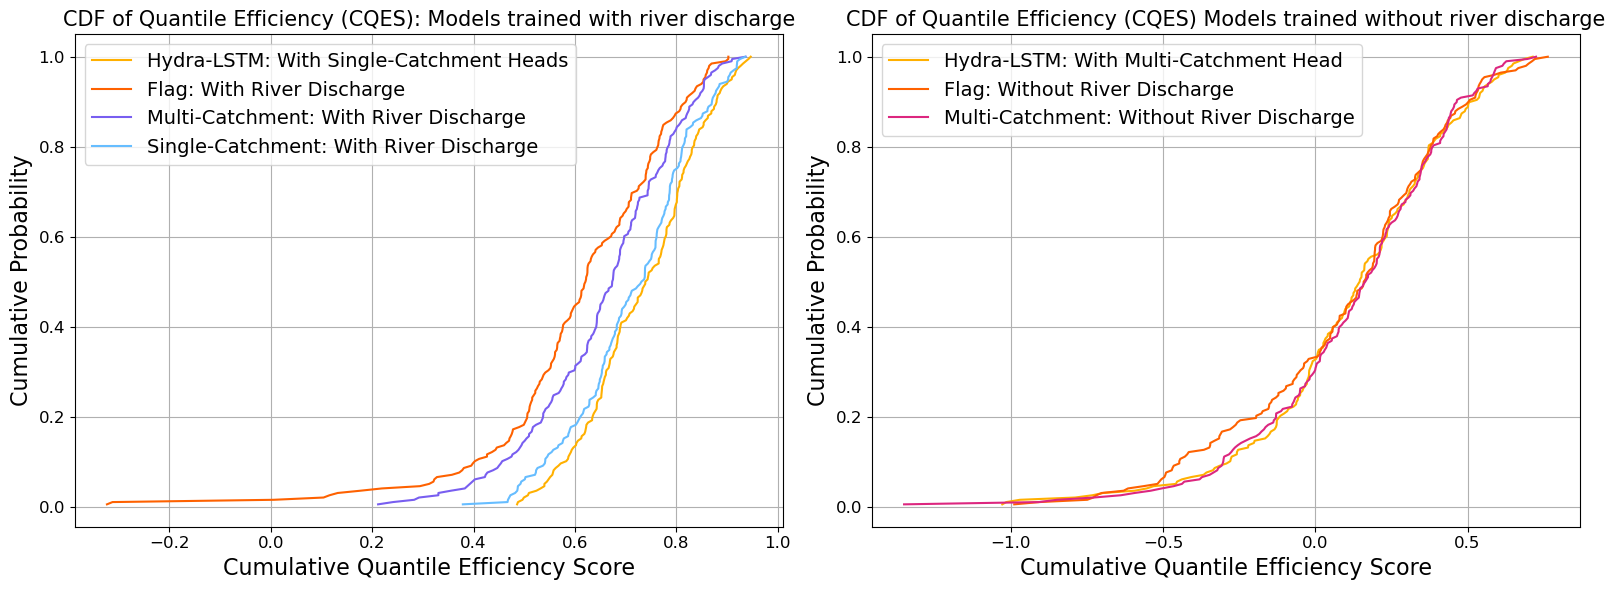

In [29]:
# Colors for the plots
orange = '#fe6100'
yellow = '#ffb000'
purple = '#785ef0'
pink = '#dc267f'
blue = '#66bdff'
grey = '#666666'


# flow_colours_list = ['yellow', 'orange', 'purple', 'blue']
# no_flow_colours_list = ['yellow', 'orange', 'purple', 'grey']
flow_colours_list = [yellow, orange, purple, blue]
no_flow_colours_list = [yellow, orange, pink, grey]


colours_list = [yellow, yellow, orange, orange, pink, purple, grey, blue]



# Names of the models with underscores
flow_names_list = [
    "Single-Catchment_Hydra_Head",    
    "Flag_LSTM:_With_River_Discharge",
    "Multi-Catchment_LSTM:_With_River_Discharge",        
    'Single-Catchment_LSTM:_With_River_Discharge',
]

no_flow_names_list = [
    "Multi-Catchment_Hydra_Head",
    'Flag_LSTM:_Without_River_Discharge',
    "Multi-Catchment_LSTM:_Without_River_Discharge",
    # 'Climatology',
]


legend_flow_names_list = [
    "Hydra-LSTM: With Single-Catchment Heads",    
    "Flag_LSTM:_With_River_Discharge",
    "Multi-Catchment_LSTM:_With_River_Discharge",        
    'Single-Catchment_LSTM:_With_River_Discharge',
]

legend_no_flow_names_list = [
    "Hydra-LSTM: With Multi-Catchment_Head",
    'Flag_LSTM:_Without_River_Discharge',
    "Multi-Catchment_LSTM:_Without_River_Discharge",
    # 'Climatology',
]


# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot CDF for Flow Models
plt.sca(axes[0])
for model, color, name in zip(flow_names_list, flow_colours_list, legend_flow_names_list):
    model_scores = extract_model_scores(CV_Scores, model)
    model = name
    model = model.replace('_', ' ')
    model = model.replace(' LSTM', '')
    plot_cdf(model_scores, model, color, log_x_axis= False)
plt.xlabel('Cumulative Quantile Efficiency Score', fontsize=16)
plt.ylabel('Cumulative Probability', fontsize=16)
plt.title('CDF of Quantile Efficiency (CQES): Models trained with river discharge', fontsize=15)
plt.legend(fontsize=14, loc = 'upper left')
plt.grid(True)


plt.grid(True)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)


# Plot CDF for No-Flow Models
plt.sca(axes[1])
for model, color, name in zip(no_flow_names_list, no_flow_colours_list, legend_no_flow_names_list):
    model_scores = extract_model_scores(CV_Scores, model)
    # remove the underscores from model
    model = name
    model = model.replace('_', ' ')
    model = model.replace(' LSTM', '')
    plot_cdf(model_scores, model, color, log_x_axis=False)
plt.xlabel('Cumulative Quantile Efficiency Score', fontsize=16)
plt.ylabel('Cumulative Probability', fontsize=16)
plt.title('CDF of Quantile Efficiency (CQES) Models trained without river discharge', fontsize=15)
plt.legend(fontsize=14)
plt.grid(True)
plt.grid(True)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

In [30]:
flow_names_list = [name.replace('_', ' ') for name in flow_names_list]
# Replace underscores with spaces in no_flow_names_list
no_flow_names_list = [name.replace('_', ' ') for name in no_flow_names_list]



ordered_columns = no_flow_names_list + flow_names_list
CV_Values.columns = CV_Values.columns.str.replace('_', ' ')

basins_df = CV_Values[ordered_columns]

In [31]:

# Highlight best performers
def highlight_best(data):
    no_flow_best = data[no_flow_names_list].idxmax(axis=1)
    flow_best = data[flow_names_list].idxmax(axis=1)

    result = pd.DataFrame('', index=data.index, columns=data.columns)
    for idx in data.index:
        result.loc[idx, no_flow_best[idx]] = 'font-weight: bold'
        result.loc[idx, flow_best[idx]] = 'font-weight: bold'
    
    return result

# Display the DataFrame with highlighting
basins_df.style.apply(highlight_best, axis=None).set_caption('Averaged Scores per Basin and Model')


,Multi-Catchment Hydra Head,Flag LSTM: Without River Discharge,Multi-Catchment LSTM: Without River Discharge,Single-Catchment Hydra Head,Flag LSTM: With River Discharge,Multi-Catchment LSTM: With River Discharge,Single-Catchment LSTM: With River Discharge
libby_reservoir_inflow,0.011135,-0.033333,0.072837,0.747018,0.625499,0.725400,0.739487
owyhee_r_bl_owyhee_dam,-0.392849,-0.186853,-0.152502,0.795397,0.312283,0.438462,0.727970
san_joaquin_river_millerton_reservoir,0.177206,0.132260,0.094082,0.872236,0.798654,0.832710,0.858827
taylor_park_reservoir_inflow,-0.071805,-0.109637,-0.057852,0.812990,0.560844,0.691289,0.789199
green_r_bl_howard_a_hanson_dam,0.208075,0.139146,0.095278,0.601593,0.474762,0.593164,0.574952
weber_r_nr_oakley,0.285198,0.340122,0.369837,0.709360,0.621753,0.671954,0.671605
detroit_lake_inflow,0.058636,-0.004443,-0.005124,0.624834,0.473053,0.568897,0.580357
virgin_r_at_virtin,0.292830,0.391554,0.387950,0.714807,0.656894,0.620283,0.704028
dillon_reservoir_inflow,0.134980,-0.125256,-0.132490,0.844616,0.743866,0.776159,0.826702
hungry_horse_reservoir_inflow,0.014562,-0.037422,0.018317,0.720471,0.652565,0.697768,0.692521


In [32]:
# Average over basins
averaged_scores = {year: {model: [] for model in model_names} for year in years}
model_name_underscore_count = {model: model.count('_') for model in model_names}

# Extract scores and compute averages
for key, score in CV_Scores.items():
    # Determine the number of underscores in the model name by matching the end of the key with known model names
    for model in model_names:
        if key.endswith(model):
            parts = key.rsplit('_', model_name_underscore_count[model] + 2)  # Split from the end
            basin = '_'.join(parts[:-model_name_underscore_count[model] - 2])  # Reconstruct the basin name
            year = parts[-model_name_underscore_count[model] - 2]
            model_name = model

        
    averaged_scores[int(year)][model_name].append(score)

# Average the scores over the basins
for year in averaged_scores:
    for model in averaged_scores[year]:
        averaged_scores[int(year)][model] = np.mean(averaged_scores[year][model])

# Create a DataFrame from the averaged scores
years_df = pd.DataFrame(averaged_scores)

years_df = years_df.T
years_df.columns = years_df.columns.str.replace('_', ' ')
years_df = years_df[ordered_columns]

# Add a row for the average over all years
years_df.loc['Average'] = years_df.mean(axis=0)
def highlight_min(s):
    is_min = s == s.min()
    return ['font-weight: bold' if v else '' for v in is_min]

# Apply the highlight_min function to each row
years_styled_df = years_df.style.apply(highlight_best, axis=None).set_caption('Averaged Scores per Basin and Model')

# Display the DataFrame with styles
years_styled_df


,Multi-Catchment Hydra Head,Flag LSTM: Without River Discharge,Multi-Catchment LSTM: Without River Discharge,Single-Catchment Hydra Head,Flag LSTM: With River Discharge,Multi-Catchment LSTM: With River Discharge,Single-Catchment LSTM: With River Discharge
2001,0.017437,0.130554,-0.006892,0.745036,0.606480,0.627206,0.693685
2003,-0.019994,-0.144528,0.088558,0.695167,0.526243,0.598523,0.674851
2005,0.148746,-0.003016,0.080391,0.742145,0.624746,0.661556,0.723454
2007,0.044526,0.023280,0.080950,0.695997,0.610127,0.617717,0.685201
2009,-0.017593,0.066133,-0.086215,0.683620,0.517155,0.612797,0.653773
2011,0.390595,0.363175,0.239196,0.780639,0.732067,0.738184,0.764722
2013,0.184822,0.166979,0.218456,0.746708,0.597685,0.659876,0.743192
2015,0.039274,0.044874,0.039527,0.764668,0.662641,0.702035,0.749632
2017,0.323888,0.216490,0.353028,0.758271,0.662734,0.713435,0.751075
2019,0.054328,0.044786,0.144884,0.685837,0.525179,0.616992,0.660265


In [33]:
years

array([2001, 2003, 2005, 2007, 2009, 2011, 2013, 2015, 2017, 2019, 2021])

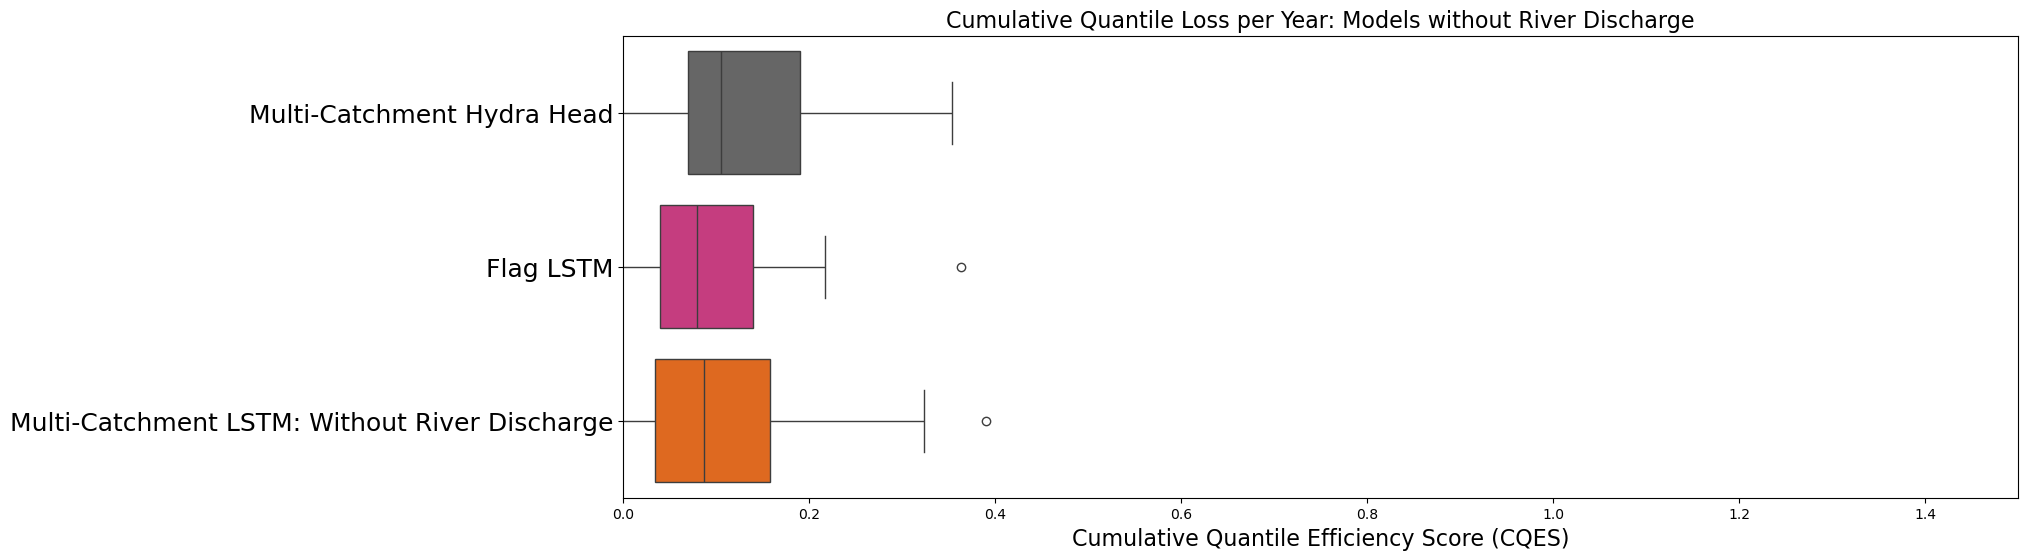

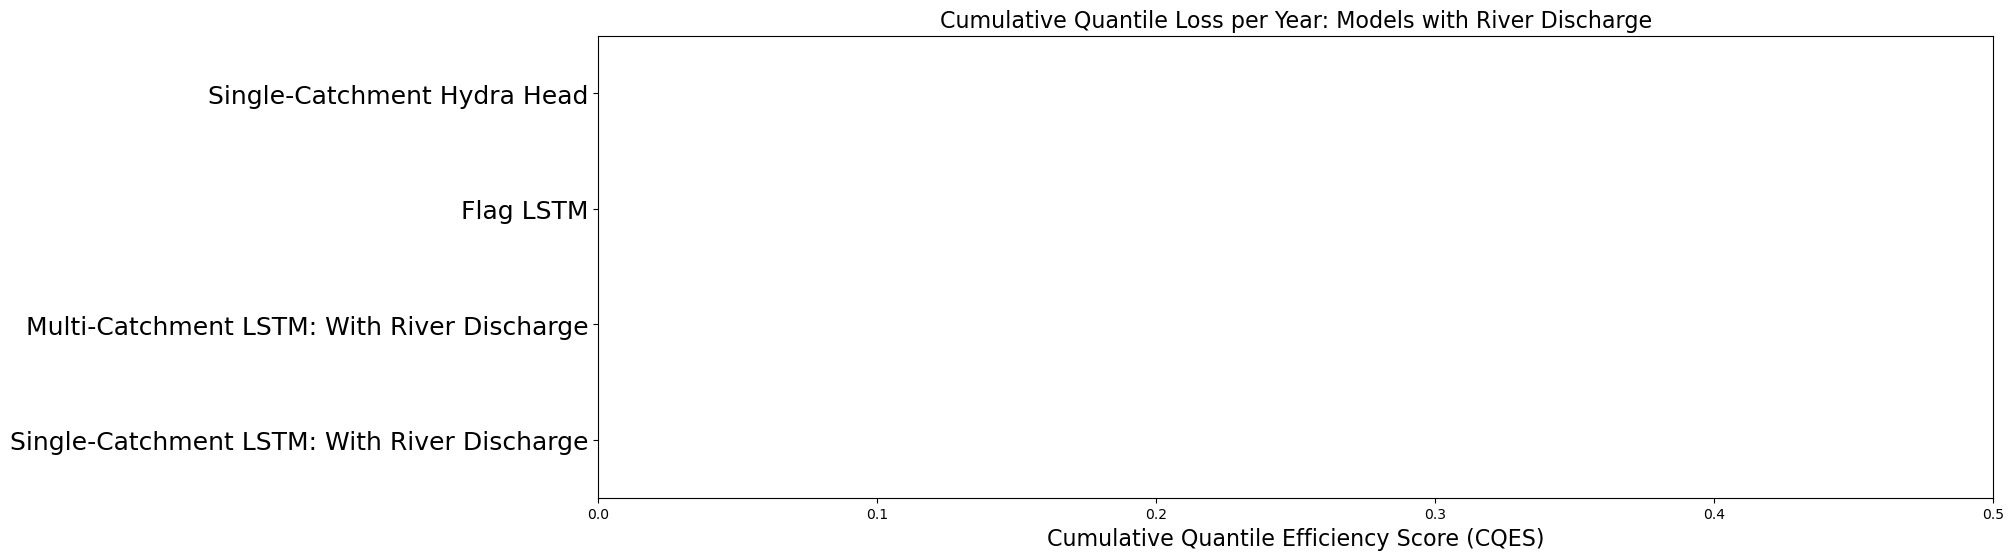

In [34]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
plt.style.use('tableau-colorblind10')
import seaborn as sns

def plot_quantile_loss(years_df, model_names, colors, title, xlim = [0, 1], custom_labels = None):
    plt.style.use('tableau-colorblind10')
    sns.color_palette('colorblind')
    
    df = years_df[model_names]
    plt.figure(figsize=(18, 6))
    sns.boxplot(data=df, orient='h', palette=colors[:len(model_names)])
    
    # Find the index of the best and worst points for the models
    best_indices = df.idxmin()
    worst_indices = df.idxmax()
    
    # Add text annotations to the plot for each column
    # for col in df.columns:
    #     best_index = best_indices[col]
    #     worst_index = worst_indices[col]
        
    #     best_point = df.loc[best_index, col]
    #     worst_point = df.loc[worst_index, col]
        
        # plt.text(best_point, df.columns.get_loc(col) - 0.4, f'Best Year: {best_index}', 
        #          ha='right', va='top', color='#ff9b00', fontsize=12)
        # plt.text(worst_point, df.columns.get_loc(col) - 0.15, f'Worst Year: {worst_index}', 
        #          ha='left', va='bottom', color='#ff9b00', fontsize=12)
   
    if custom_labels:
        plt.yticks(ticks=range(len(custom_labels)), labels=custom_labels, fontsize=18)
    else:
        plt.yticks(ticks=range(len(model_names)), labels=model_names, fontsize=18)
    
    plt.xlim(xlim)
    plt.xlabel('Cumulative Quantile Efficiency Score (CQES)', fontsize=16)
    plt.yticks(fontsize=18)
    plt.title(title, fontsize=16)
    plt.show()

Rename_Flag_Flow = flow_names_list.copy()
Rename_Flag_No_Flow = no_flow_names_list.copy()
Rename_Flag_Flow[1] = 'Flag LSTM'
Rename_Flag_No_Flow[1] = 'Flag LSTM'


# Plot for No-Flow Models
plot_quantile_loss(years_df[::-1], no_flow_names_list[::-1], no_flow_colours_list[::-1], 
                   'Cumulative Quantile Loss per Year: Models without River Discharge', [0, 1.5], custom_labels = Rename_Flag_No_Flow)

# Plot for Flow Models
plot_quantile_loss(years_df[::-1], flow_names_list[::-1], flow_colours_list[::-1], 
                   'Cumulative Quantile Loss per Year: Models with River Discharge', [0, 0.5], custom_labels = Rename_Flag_Flow)


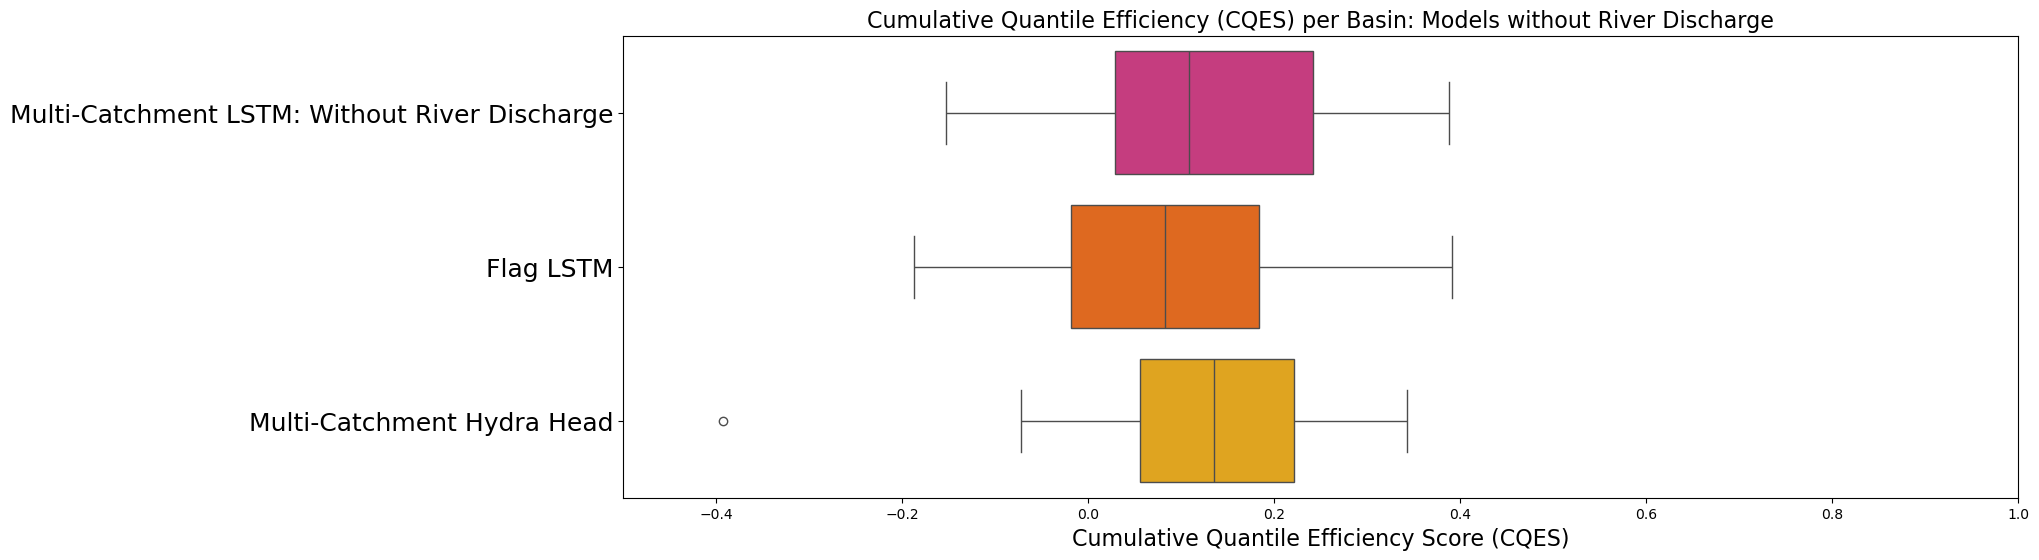

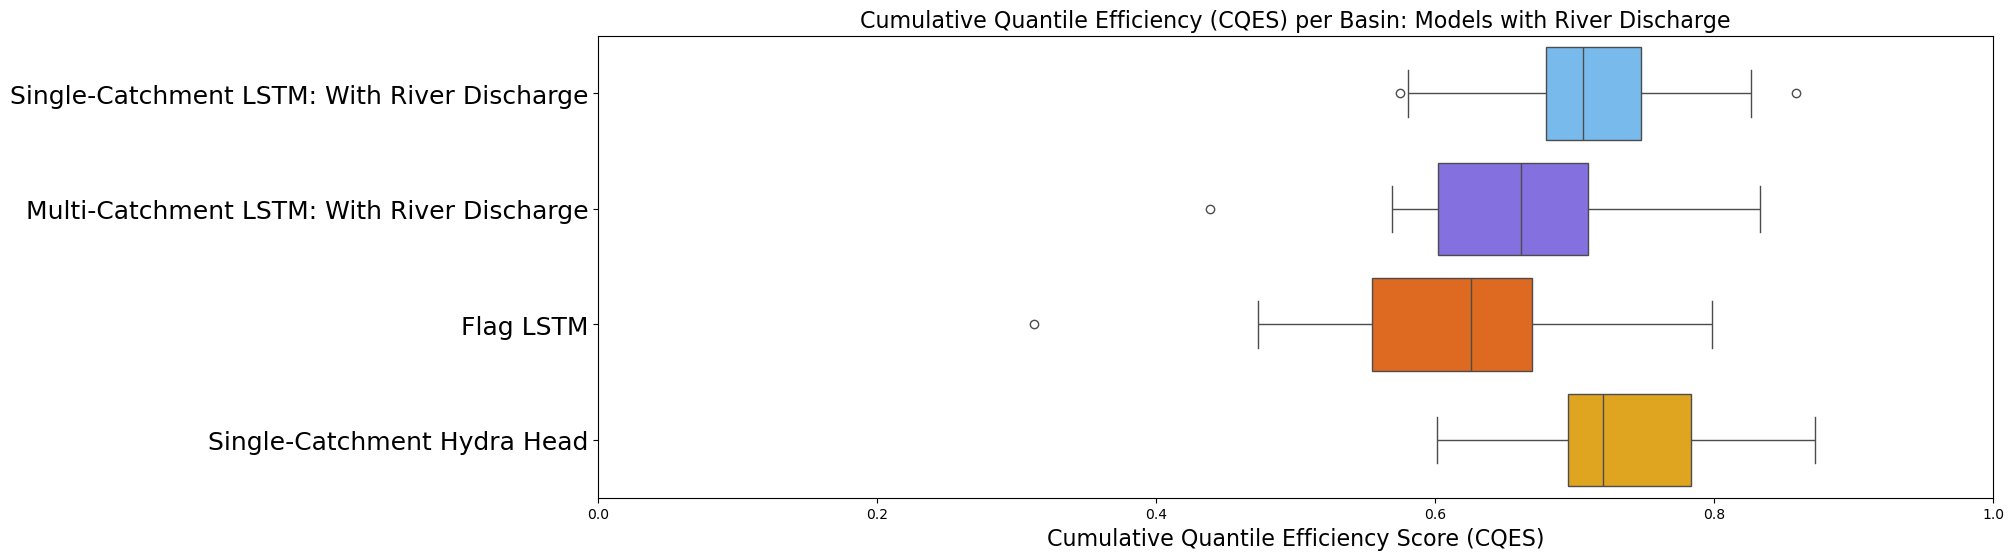

In [35]:

plot_quantile_loss(basins_df[::-1], no_flow_names_list[0:3][::-1], no_flow_colours_list[0:3][::-1], 
                   'Cumulative Quantile Efficiency (CQES) per Basin: Models without River Discharge', [-0.5, 1], custom_labels = Rename_Flag_No_Flow[0:3][::-1])


plot_quantile_loss(basins_df[::-1], flow_names_list[::-1], flow_colours_list[::-1], 
                   'Cumulative Quantile Efficiency (CQES) per Basin: Models with River Discharge', [0, 1], custom_labels = Rename_Flag_Flow[::-1])




In [36]:
site_id = pd.read_csv('/data/Hydra_Work/Sep_2024_Data/site_id_metadata.csv', index_col=0)


In [37]:
basins

['libby_reservoir_inflow',
 'owyhee_r_bl_owyhee_dam',
 'san_joaquin_river_millerton_reservoir',
 'taylor_park_reservoir_inflow',
 'green_r_bl_howard_a_hanson_dam',
 'weber_r_nr_oakley',
 'detroit_lake_inflow',
 'virgin_r_at_virtin',
 'dillon_reservoir_inflow',
 'hungry_horse_reservoir_inflow',
 'stehekin_r_at_stehekin',
 'pecos_r_nr_pecos',
 'snake_r_nr_heise',
 'yampa_r_nr_maybell',
 'colville_r_at_kettle_falls',
 'missouri_r_at_toston',
 'merced_river_yosemite_at_pohono_bridge',
 'animas_r_at_durango']

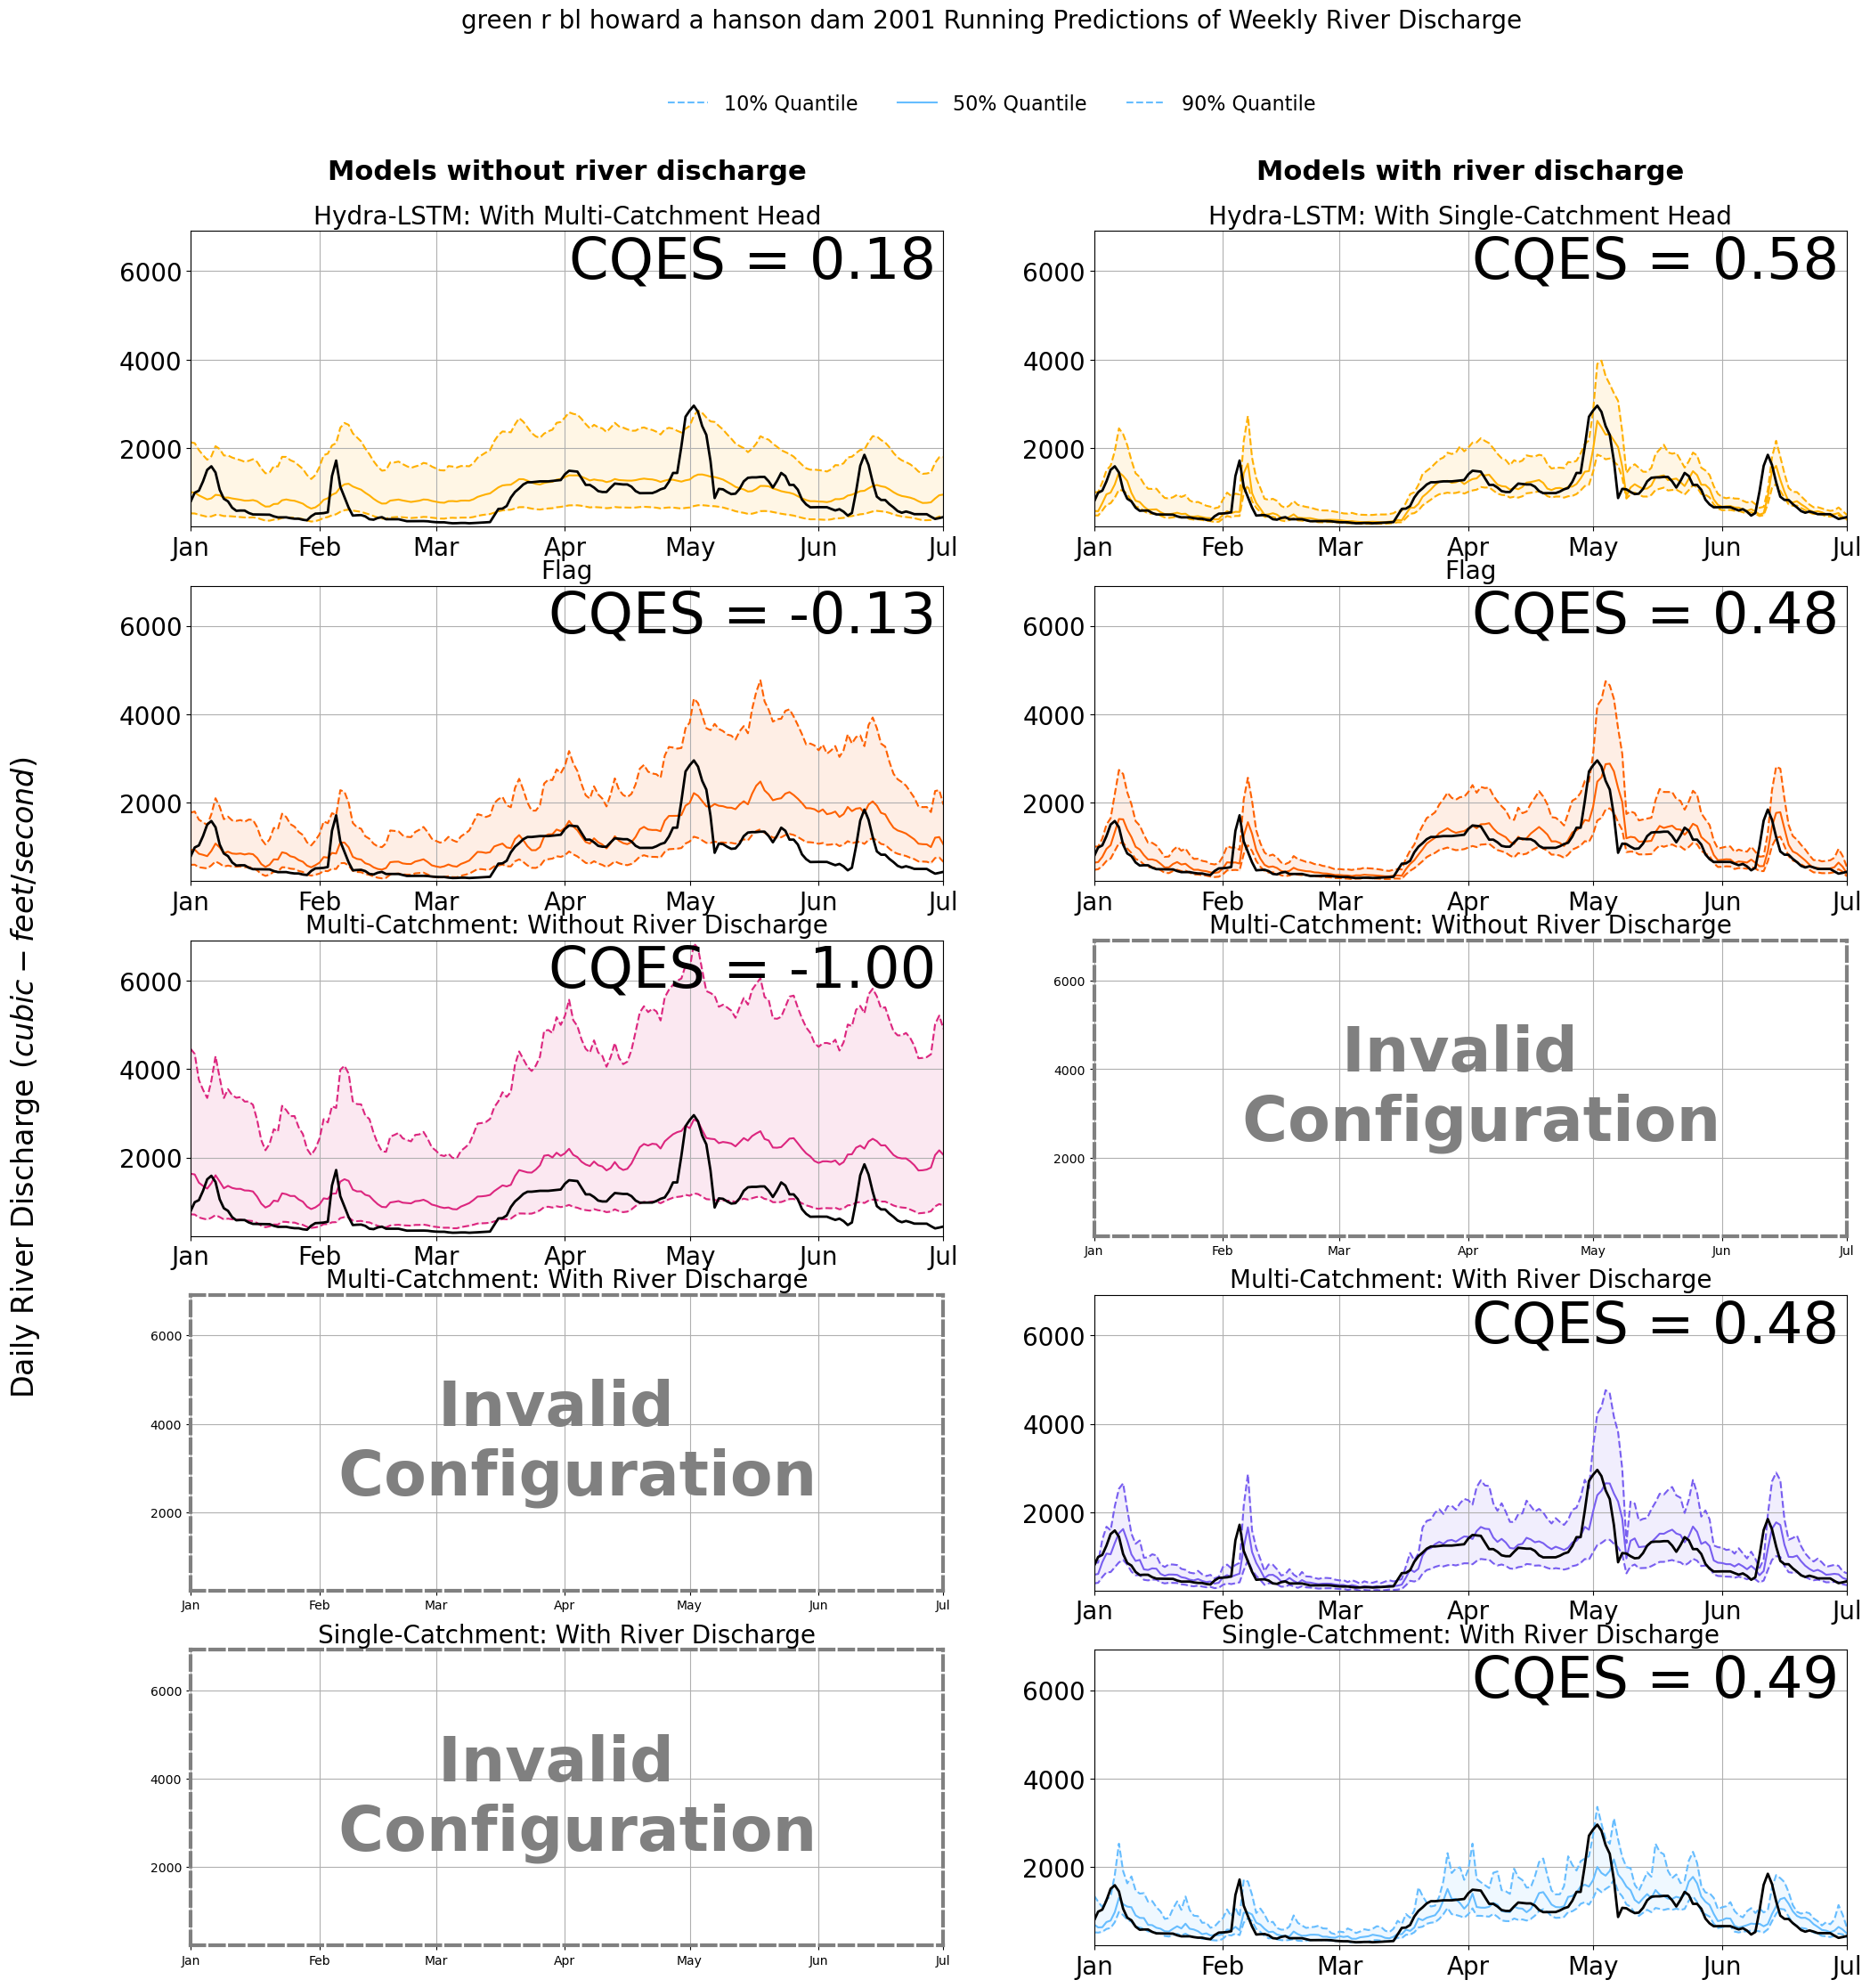

In [45]:
import seaborn as sns
import numpy as np
test_year = 2001
model_year = test_year #2016

years = np.arange(2001,2023,2)
years_to_include = [year for year in years if year != test_year]


    
climatological_flows = calculate_climatological_flows(years_to_include, daily_flow)


basin = 'green_r_bl_howard_a_hanson_dam'

# basin = 'animas_r_at_durango'
# basin =  'missouri_r_at_toston'
	

start_season_date = f'{test_year}-01-01' 
end_season_date = f'{test_year}-07-01'

day = 1

                



        
General_LSTM_Model = torch.load(f'/data/Hydra_Work/Sep_{day}_Day_No_Forecast_Validation_Models/{test_year}/General_LSTM_Model/General_LSTM.pth')
General_LSTM_No_Flow_Model = torch.load(f'/data/Hydra_Work/Sep_{day}_Day_No_Forecast_Validation_Models/{test_year}/General_LSTM_No_Flow_Model/General_LSTM.pth')
                                          
Flag_LSTM = torch.load(f'/data/Hydra_Work/Sep_{day}_Day_No_Forecast_Validation_Models/{test_year}/Flag_LSTM_Model/Flag_LSTM.pth')
# Flag_LSTM = torch.load(f'/data/Hydra_Work/Sep_1_Day_No_Forecast_Validation_Models_Seperate_V2/2001/Flag_LSTM_Model_075/Flag_LSTM.pth')


Hydra_General_Head = torch.load(f'/data/Hydra_Work/Sep_{day}_Day_No_Forecast_Validation_Models_Seperate_V2/{test_year}/General_Head_Model/Hydra_Head_LSTM.pth')
Hydra_Body = torch.load(f'/data/Hydra_Work/Sep_{day}_Day_No_Forecast_Validation_Models_Seperate_V2/{test_year}/General_Head_Model/Hydra_Body_LSTM.pth')
Specific_Heads = {}
Specific_Models = {}
Specific_Heads[f'{basin}'] = torch.load(f'/data/Hydra_Work/Sep_{day}_Day_No_Forecast_Validation_Models_Seperate_V2/{test_year}/Basin_Head_Model/{basin}.path')
Specific_Models[f'{basin}'] = torch.load(f'/data/Hydra_Work/Sep_{day}_Day_No_Forecast_Validation_Models/{test_year}/Specific_LSTM_Model/{basin}_specific.pth') 


Climatology_Guesses, Basin_Head_Guesses, General_Head_Guesses,  Truth = test_weekly_performance_hydra(basin, Hydra_Body, Hydra_General_Head, Specific_Heads, era5, seasonal_forecasts, daily_flow, climatological_flows, climate_indices, static_variables, device, end_season_date, start_season_date,  furthest_distance = 120,  group_lengths = [1], feed_forcing = False, days = day)
Climatology_Guesses, General_LSTM_Guesses,  _ = test_weekly_performance(basin, General_LSTM_Model, era5, seasonal_forecasts, daily_flow, climatological_flows, climate_indices, static_variables, device, end_season_date, start_season_date,  furthest_distance = 120,  group_lengths = [1], feed_forcing = False, specialised = False, days = day)
_, Specific_LSTM_Guesses, _ = test_weekly_performance(basin, Specific_Models, era5, seasonal_forecasts, daily_flow, climatological_flows, climate_indices, static_variables, device, end_season_date, start_season_date,  furthest_distance = 120,  group_lengths = [1], feed_forcing = False, specialised = True, days = day)
_, General_LSTM_No_Flow_Guesses,  _ = test_weekly_performance(basin, General_LSTM_No_Flow_Model, era5, seasonal_forecasts, daily_flow, climatological_flows, climate_indices, static_variables, device, end_season_date, start_season_date,  furthest_distance = 120,  group_lengths = [1], feed_forcing = False, specialised = False, Flow = False, days = day)
_, No_Flow_Flag_LSTM_Guesses, _ = test_weekly_performance(basin, Flag_LSTM, era5, seasonal_forecasts, daily_flow, climatological_flows, climate_indices, static_variables, device, end_season_date, start_season_date, furthest_distance=120, group_lengths=[1], feed_forcing=False, days = day , specialised=False, p = 0)
_, Flag_LSTM_Guesses, _ = test_weekly_performance(basin, Flag_LSTM, era5, seasonal_forecasts, daily_flow, climatological_flows, climate_indices, static_variables, device, end_season_date, start_season_date, furthest_distance=120, group_lengths=[1], feed_forcing=False, days = day, specialised=False, p = 1)


Days = len(Basin_Head_Guesses)
Truth = np.array(Truth)
Climatology_Guesses = np.array(Climatology_Guesses).reshape(Days , 3)
Basin_Head_Guesses = np.array(Basin_Head_Guesses).reshape(Days , 3)
General_Head_Guesses = np.array(General_Head_Guesses).reshape(Days , 3)
Flag_LSTM_Guesses = np.array(Flag_LSTM_Guesses).reshape(Days, 3)
No_Flow_Flag_LSTM_Guesses = np.array(No_Flow_Flag_LSTM_Guesses).reshape(Days, 3)
General_LSTM_Guesses = np.array(General_LSTM_Guesses).reshape(Days , 3)
General_LSTM_No_Flow_Guesses = np.array(General_LSTM_No_Flow_Guesses).reshape(Days , 3)
Specific_LSTM_Guesses = np.array(Specific_LSTM_Guesses).reshape(Days , 3)




guesses_list = [
    General_Head_Guesses, Basin_Head_Guesses,
    No_Flow_Flag_LSTM_Guesses, Flag_LSTM_Guesses,
    General_LSTM_No_Flow_Guesses, None,
    None, General_LSTM_Guesses,
    None,
    Specific_LSTM_Guesses,    

]



    
scaler = joblib.load('/data/Hydra_Work/Sep_2024_Data/Sep_05_scalers/daily_flow_scaler.save')

Truth = np.exp(scaler.inverse_transform(Truth))*site_id['drainage_area'][basin]
Climatology_Guesses = np.exp(scaler.inverse_transform(Climatology_Guesses))*site_id['drainage_area'][basin]

# inverse transform arrays in guesses_list
guesses_list = [np.exp(scaler.inverse_transform(guess))*site_id['drainage_area'][basin] if guess is not None else None for guess in guesses_list]


climatology_loss = quantile_loss(Climatology_Guesses, Truth, )
losses = []
for guess in guesses_list:
    if guess is None:
        loss = None
    else:
        loss = 1 - (quantile_loss(guess, Truth, )/climatology_loss)
        
    losses.append(loss)

names_list = [
    "Hydra-LSTM: With Multi-Catchment_Head", "Hydra-LSTM: With Single-Catchment_Head",    
    'Flag_LSTM', 'Flag_LSTM',
    "Multi-Catchment_LSTM:_Without_River_Discharge", "Multi-Catchment_LSTM:_Without_River_Discharge",
    "Multi-Catchment_LSTM:_With_River_Discharge", "Multi-Catchment_LSTM:_With_River_Discharge",
    'Single-Catchment_LSTM:_With_River_Discharge',
    "Single-Catchment_LSTM:_With_River_Discharge",
    
]

names_list = [name.replace('_LSTM', '') for name in names_list]
names_list = [name.replace('_', ' ') for name in names_list]



orange = '#fe6100'
yellow = '#ffb000'
purple = '#785ef0'
pink = '#dc267f'
blue = '#66bdff'
grey = '#666666'
colours_list = [yellow, yellow, orange, orange, pink, grey, grey, purple, grey, blue]

all_plot_predictions(guesses_list, names_list, Truth, losses, f'{basin}', test_year, start_season_date, end_season_date, colours_list)


In [41]:
for test_year in years:

    model_year = test_year #2016

    years = np.arange(2001,2023,2)
    years_to_include = [year for year in years if year != test_year]


        
    climatological_flows = calculate_climatological_flows(years_to_include, daily_flow)


    basin = 'green_r_bl_howard_a_hanson_dam'

    # basin = 'animas_r_at_durango'
    # basin =  'missouri_r_at_toston'
        

    start_season_date = f'{test_year}-01-01' 
    end_season_date = f'{test_year}-07-01'

    day = 1

                    



            
    General_LSTM_Model = torch.load(f'/data/Hydra_Work/Sep_{day}_Day_No_Forecast_Validation_Models/{test_year}/General_LSTM_Model/General_LSTM.pth')
    General_LSTM_No_Flow_Model = torch.load(f'/data/Hydra_Work/Sep_{day}_Day_No_Forecast_Validation_Models/{test_year}/General_LSTM_No_Flow_Model/General_LSTM.pth')
                                            
    Flag_LSTM = torch.load(f'/data/Hydra_Work/Sep_{day}_Day_No_Forecast_Validation_Models/{test_year}/Flag_LSTM_Model/Flag_LSTM.pth')
    # Flag_LSTM = torch.load(f'/data/Hydra_Work/Sep_1_Day_No_Forecast_Validation_Models_Seperate_V2/2001/Flag_LSTM_Model_075/Flag_LSTM.pth')


    Hydra_General_Head = torch.load(f'/data/Hydra_Work/Sep_{day}_Day_No_Forecast_Validation_Models_Seperate_V2/{test_year}/General_Head_Model/Hydra_Head_LSTM.pth')
    Hydra_Body = torch.load(f'/data/Hydra_Work/Sep_{day}_Day_No_Forecast_Validation_Models_Seperate_V2/{test_year}/General_Head_Model/Hydra_Body_LSTM.pth')
    Specific_Heads = {}
    Specific_Models = {}
    Specific_Heads[f'{basin}'] = torch.load(f'/data/Hydra_Work/Sep_{day}_Day_No_Forecast_Validation_Models_Seperate_V2/{test_year}/Basin_Head_Model/{basin}.path')
    Specific_Models[f'{basin}'] = torch.load(f'/data/Hydra_Work/Sep_{day}_Day_No_Forecast_Validation_Models/{test_year}/Specific_LSTM_Model/{basin}_specific.pth') 


    Climatology_Guesses, Basin_Head_Guesses, General_Head_Guesses,  Truth = test_weekly_performance_hydra(basin, Hydra_Body, Hydra_General_Head, Specific_Heads, era5, seasonal_forecasts, daily_flow, climatological_flows, climate_indices, static_variables, device, end_season_date, start_season_date,  furthest_distance = 120,  group_lengths = [1], feed_forcing = False, days = day)
    Climatology_Guesses, General_LSTM_Guesses,  _ = test_weekly_performance(basin, General_LSTM_Model, era5, seasonal_forecasts, daily_flow, climatological_flows, climate_indices, static_variables, device, end_season_date, start_season_date,  furthest_distance = 120,  group_lengths = [1], feed_forcing = False, specialised = False, days = day)
    _, Specific_LSTM_Guesses, _ = test_weekly_performance(basin, Specific_Models, era5, seasonal_forecasts, daily_flow, climatological_flows, climate_indices, static_variables, device, end_season_date, start_season_date,  furthest_distance = 120,  group_lengths = [1], feed_forcing = False, specialised = True, days = day)
    _, General_LSTM_No_Flow_Guesses,  _ = test_weekly_performance(basin, General_LSTM_No_Flow_Model, era5, seasonal_forecasts, daily_flow, climatological_flows, climate_indices, static_variables, device, end_season_date, start_season_date,  furthest_distance = 120,  group_lengths = [1], feed_forcing = False, specialised = False, Flow = False, days = day)
    _, No_Flow_Flag_LSTM_Guesses, _ = test_weekly_performance(basin, Flag_LSTM, era5, seasonal_forecasts, daily_flow, climatological_flows, climate_indices, static_variables, device, end_season_date, start_season_date, furthest_distance=120, group_lengths=[1], feed_forcing=False, days = day , specialised=False, p = 0)
    _, Flag_LSTM_Guesses, _ = test_weekly_performance(basin, Flag_LSTM, era5, seasonal_forecasts, daily_flow, climatological_flows, climate_indices, static_variables, device, end_season_date, start_season_date, furthest_distance=120, group_lengths=[1], feed_forcing=False, days = day, specialised=False, p = 1)


    Days = len(Basin_Head_Guesses)
    Truth = np.array(Truth)
    Climatology_Guesses = np.array(Climatology_Guesses).reshape(Days , 3)
    Basin_Head_Guesses = np.array(Basin_Head_Guesses).reshape(Days , 3)
    General_Head_Guesses = np.array(General_Head_Guesses).reshape(Days , 3)
    Flag_LSTM_Guesses = np.array(Flag_LSTM_Guesses).reshape(Days, 3)
    No_Flow_Flag_LSTM_Guesses = np.array(No_Flow_Flag_LSTM_Guesses).reshape(Days, 3)
    General_LSTM_Guesses = np.array(General_LSTM_Guesses).reshape(Days , 3)
    General_LSTM_No_Flow_Guesses = np.array(General_LSTM_No_Flow_Guesses).reshape(Days , 3)
    Specific_LSTM_Guesses = np.array(Specific_LSTM_Guesses).reshape(Days , 3)




    guesses_list = [
        General_Head_Guesses, Basin_Head_Guesses,
        No_Flow_Flag_LSTM_Guesses, Flag_LSTM_Guesses,
        General_LSTM_No_Flow_Guesses, None,
        None, General_LSTM_Guesses,
        None,
        Specific_LSTM_Guesses,    

    ]



        
    scaler = joblib.load('/data/Hydra_Work/Sep_2024_Data/Sep_05_scalers/daily_flow_scaler.save')

    Truth = np.exp(scaler.inverse_transform(Truth))*site_id['drainage_area'][basin]
    Climatology_Guesses = np.exp(scaler.inverse_transform(Climatology_Guesses))*site_id['drainage_area'][basin]

    # inverse transform arrays in guesses_list
    guesses_list = [np.exp(scaler.inverse_transform(guess))*site_id['drainage_area'][basin] if guess is not None else None for guess in guesses_list]


    climatology_loss = quantile_loss(Climatology_Guesses, Truth, )
    losses = []
    for guess in guesses_list:
        if guess is None:
            loss = None
        else:
            loss = 1 - (quantile_loss(guess, Truth, )/climatology_loss)
            
        losses.append(loss)

    names_list = [
        "Multi-Catchment_Hydra_Head", "Single-Catchment_Hydra_Head",    
        'Flag LSTM', 'Flag LSTM',
        "Multi-Catchment_LSTM:_Without_River_Discharge", "Multi-Catchment_LSTM:_Without_River_Discharge",
        "Multi-Catchment_LSTM:_With_River_Discharge", "Multi-Catchment_LSTM:_With_River_Discharge",
        'Single-Catchment_LSTM:_With_River_Discharge',
        "Single-Catchment_LSTM:_With_River_Discharge",
        
    ]
    names_list = [name.replace('_', ' ') for name in names_list]



    orange = '#fe6100'
    yellow = '#ffb000'
    purple = '#785ef0'
    pink = '#dc267f'
    blue = '#66bdff'
    grey = '#666666'
    colours_list = [yellow, yellow, orange, orange, pink, grey, grey, purple, grey, blue]

    all_plot_predictions(guesses_list, names_list, Truth, losses, f'{basin}', test_year, start_season_date, end_season_date, colours_list)  

FileNotFoundError: [Errno 2] No such file or directory: '/data/Hydra_Work/Sep_1_Day_No_Forecast_Validation_Models/2000/General_LSTM_No_Flow_Model/General_LSTM.pth'

In [42]:
from datetime import datetime, timedelta
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def all_plot_predictions(guesses_list, names_list, Truth, scores, basin, year, start_date, end_date, colors):
    num_models = len(guesses_list)
    num_cols = 2
    num_rows = (num_models + 1) // num_cols  
    
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(12*num_cols, 5 * num_rows), sharex=False, sharey=True)
    axs = axs.flatten() 
    
    start_date = datetime.strptime(start_date, '%Y-%m-%d')
    end_date = datetime.strptime(end_date, '%Y-%m-%d')
    
    
    # Calculate the number of days and generate date range
    days = (end_date - start_date).days
    dates = [start_date + timedelta(days=i) for i in range(days)]

    for i in range(num_models):
        guesses = guesses_list[i]
        name = names_list[i]
        color = colors[i]
        
        if guesses is not None:
            axs[i].fill_between(range(len(guesses)), guesses[:, 0], guesses[:, 2], color=color, alpha=0.1)
            Percentile_10, = axs[i].plot(guesses[:, 0], color=color, linestyle='--')
            Percentile_50, = axs[i].plot(guesses[:, 1], color=color, linestyle='-')
            Percentile_90, = axs[i].plot(guesses[:, 2], color=color, linestyle='--')
            Truth_line, = axs[i].plot(Truth, color='black', linestyle='-', linewidth=2)
            
            axs[i].set_title(f'{name}', fontsize=20)
            
            # Display cumulative loss score in the top right corner
            axs[i].text(0.99, 0.99, f'CQES = {scores[i]:.2f}',
                        verticalalignment='top', horizontalalignment='right',
                        transform=axs[i].transAxes,
                        color='black', fontsize=46)
            
            axs[i].tick_params(axis='both', which='major', labelsize=20)
            axs[i].tick_params(axis='both', which='minor', labelsize=20)
            axs[i].grid(True)
        else:
            axs[i].set_title(f'{name}', fontsize=20)
            axs[i].plot([], [])
            axs[i].grid(True)
            for spine in axs[i].spines.values():
                spine.set_linestyle('--')
                spine.set_linewidth(3)
                spine.set_color('grey')

           # Add "Cannot Use" text in the center
            axs[i].text(0.5, 0.5, 'Invalid \n Configuration', horizontalalignment='center', verticalalignment='center', transform=axs[i].transAxes, color='grey', fontsize= 50, weight='bold')

            # Add a big red "X"
            # axs[i].plot([0, 1], [0, 1], transform=axs[i].transAxes, color='red', linewidth=4)
            # axs[i].plot([0, 1], [1, 0], transform=axs[i].transAxes, color='red', linewidth=4)


    fig.legend([Percentile_10, Percentile_50, Percentile_90], ['10% Quantile', '50% Quantile', '90% Quantile'], loc='upper center', fontsize=16, ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.95), facecolor='grey')

    # Remove any extra axes
    if num_models % num_cols != 0:
        for j in range(num_models, len(axs)):
            fig.delaxes(axs[j])
            
            
    all_values = Truth            
    for guesses in guesses_list:
        if guesses is not None:
            all_values = np.append(all_values, guesses[:, 0])
            all_values = np.append(all_values, guesses[:, 1])
            all_values = np.append(all_values, guesses[:, 2])
    y_min, y_max = all_values.min(), all_values.max()
    y_min, y_max = all_values.min(), all_values.max()
    
    for ax in axs:
        # Format the x-axis to show months
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
        
        # Remove the buffer around the x-axis and y-axis
        ax.set_xlim([0, len(Truth) - 1])
        ax.set_ylim([y_min*0.99, y_max*1.01])

    fig.text(0.04, 0.5, 'Daily River Discharge ($cubic-feet/second$)', va='center', rotation='vertical', fontsize=24)

    # Ensure y-ticks are displayed on both columns
    for ax in axs:
        ax.yaxis.set_label_position("left")
        ax.yaxis.tick_left()
        ax.yaxis.set_tick_params(which='both', labelleft=True)
 

    if num_rows > 0:
        axs[0].annotate('Models without river discharge', xy=(0.5, 1.2), xycoords='axes fraction', ha='center', va='center', fontsize=22, weight='bold')
    if num_cols > 1 and num_rows > 0:
        axs[1].annotate('Models with river discharge', xy=(0.5, 1.2), xycoords='axes fraction', ha='center', va='center', fontsize=22, weight='bold')

    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)


    formatted_basin = basin.replace('_', ' ')
    plt.suptitle(f'{formatted_basin} {year} Running Predictions of Weekly River Discharge', fontsize=20)

    # Show the plot
    plt.show()


In [40]:
import seaborn as sns
test_year = 2001
model_year = test_year #2016
day = 1
years = np.arange(2000,2024,2)
years_to_include = [year for year in years if year != test_year]
climatological_flows = calculate_climatological_flows(years_to_include, daily_flow)


basin = 'green_r_bl_howard_a_hanson_dam'
daily_flow['green_r_bl_howard_a_hanson_dam']

start_season_date = f'{test_year}-01-01' 
end_season_date = f'{test_year}-07-01'

Hydra_General_Head = torch.load(f'/data/Hydra_Work/{day}_Day_No_Forecast_Validation_Models/{model_year}/General_Head_Model/Hydra_Head_LSTM.pth')
Hydra_Body = torch.load(f'/data/Hydra_Work/{day}_Day_No_Forecast_Validation_Models/{model_year}/General_Head_Model/Hydra_Body_LSTM.pth')
Specific_Heads = {}
Specific_Heads[f'{basin}'] = torch.load(f'/data/Hydra_Work/{day}_Day_No_Forecast_Validation_Models/{model_year}/Basin_Head_Model/{basin}.path')
        

Climatology_Guesses, Basin_Head_Guesses, General_Head_Guesses,  Truth = test_weekly_performance_hydra(basin, Hydra_Body, Hydra_General_Head, Specific_Heads, era5, seasonal_forecasts, daily_flow, climatological_flows, climate_indices, static_variables, device, end_season_date, start_season_date,  furthest_distance = 120,  group_lengths = [1], feed_forcing = False, days = day)


Days = len(Basin_Head_Guesses)
NP_Truth = np.array(Truth).reshape(Days, 1)
Basin_Head_Guesses = np.array(Basin_Head_Guesses).reshape(Days , 3)
General_Head_Guesses = np.array(General_Head_Guesses).reshape(Days , 3)


guesses_list = [
    General_Head_Guesses,
    Basin_Head_Guesses,
]

names_list = [
    'General Hydra Head',
    'Basin Hydra Head',      
]

scaler = joblib.load('/data/Hydra_Work/Rodeo_Data/daily_flow_scaler.save')


Truth = scaler.inverse_transform(Truth)
# inverse transform arrays in guesses_list
guesses_list = [scaler.inverse_transform(guess) if guess is not None else None for guess in guesses_list]



losses = []
for guess in guesses_list:
    loss = quantile_loss(guess, NP_Truth)
    losses.append(loss)


yellow = '#ffb000'
colours_list = [yellow, yellow]

all_plot_predictions(guesses_list, names_list, Truth, losses, f'{basin}', test_year, start_season_date, end_season_date, colours_list)


FileNotFoundError: [Errno 2] No such file or directory: '/data/Hydra_Work/1_Day_No_Forecast_Validation_Models/2001/General_Head_Model/Hydra_Head_LSTM.pth'

In [ ]:
plt.figure(figsize=(10, 5))
ax = plt.gca()  # Get current axis

# Plot the Truth line
ax.plot(Truth, color='black', label='Truth')

# Plot the quantile data
ax.fill_between(range(len(guesses_list[1][:,0])), guesses_list[1][:, 0], guesses_list[1][:, 2], color=colours_list[0], alpha=0.1, label='Prediction Interval')
ax.plot(guesses_list[1][:,0], color=colours_list[0], linestyle='--', label='10th Percentile')
ax.plot(guesses_list[1][:, 1], color=colours_list[0], linestyle='-', label='50th Percentile')
ax.plot(guesses_list[1][:, 2], color=colours_list[0], linestyle='--', label='90th Percentile')

# Format the x-axis to show months
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# Set x-axis and y-axis limits
ax.set_xlim([0, len(Truth) - 1])
# y_min, y_max = 0, max(np.max(guesses_list[1][:, 2]), np.max(Truth))
# ax.set_ylim([y_min * 0.99, y_max * 1.05])

# Add titles and labels
ax.set_xlabel('Date', fontsize=14)
ax.set_ylabel('Daily River Discharge ($ft^{3}/s$)', fontsize=14)
plt.title('River Discharge Predictions for Howard A Hanson Dam 2017', fontsize=16)

# Add vertical label for the y-axis
fig = plt.gcf()  # Get current figure
# fig.text(0.04, 0.5, 'Daily River Discharge ($cubic-feet/second$)', va='center', rotation='vertical', fontsize=24)

# Add a legend to distinguish between plots
plt.legend()

# Show the plot
plt.show()


In [ ]:
Days = len(Flag_LSTM_Guesses)
losses_basin_head = np.zeros(Days)
losses_general_head = np.zeros(Days)
losses_no_flow_lstm = np.zeros(Days)
losses_flag_lstm = np.zeros(Days)

for day in range(Days):
    losses_basin_head[day] = quantile_loss(Basin_Head_Guesses[day, :].reshape(1, -1), Truth[day])
    losses_general_head[day] = quantile_loss(General_Head_Guesses[day, :].reshape(1, -1), Truth[day])
    losses_no_flow_lstm[day] = quantile_loss(No_Flow_Flag_LSTM_Guesses[day, :].reshape(1, -1), Truth[day])
    losses_flag_lstm[day] = quantile_loss(Flag_LSTM_Guesses[day, :].reshape(1, -1), Truth[day])
    
    
# Compute differences in losses
difference_flow = losses_flag_lstm - losses_basin_head
difference_no_flow = losses_general_head - losses_no_flow_lstm


# Example data for difference in losses
start_date = datetime.strptime(start_season_date, '%Y-%m-%d')
end_date = datetime.strptime(end_season_date, '%Y-%m-%d')

# Create a single figure with subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), sharex=True)

# Plot for difference in losses with flow models
ax1.set_title(f'Difference in Losses (Flow Models), average score = {np.mean(difference_flow):.3f}')
ax1.axhline(0, color='black', linestyle='--', linewidth=0.5)
for day in range(Days - 1):
    color = 'green' if difference_flow[day] >= 0 else 'red'
    ax1.plot([day, day + 1], [difference_flow[day], difference_flow[day + 1]], color=color, linewidth=2)
ax1.set_ylabel('Difference in Quantile Loss')
ax1.grid(True)

# Plot for difference in losses without flow models
ax2.set_title(f'Difference in Losses (No Flow Models), average score = {np.mean(difference_no_flow):.3f}')
ax2.axhline(0, color='black', linestyle='--', linewidth=0.5)
for day in range(Days - 1):
    color = 'green' if difference_no_flow[day] >= 0 else 'red'
    ax2.plot([day, day + 1], [difference_no_flow[day], difference_no_flow[day + 1]], color=color, linewidth=2)
ax2.set_xlabel('Day')
ax2.set_ylabel('Difference in Quantile Loss')
ax2.grid(True)

# Format x-axis to show months
fig.autofmt_xdate()
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.tight_layout()
plt.show()
